# George Boufis / f3352504
## Assignment in Deep Learning
### Deep Generative Models: From 2D Manifolds to Image Synthesis


### Imports, Reproducibility, and Device Setup

In this cell, we import the main libraries used for numerical computation, plotting, and building neural networks with PyTorch. We also set a fixed random seed so that the experiments are reproducible across different runs.

Since Part 1 of the assignment must be executed on CPU only, we explicitly set the device to cpu.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import TensorDataset, DataLoader, random_split

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# CPU only, as required
device = torch.device("cpu")
print("Device:", device)

Device: cpu


### Synthetic 8-Mode GMM Dataset

We generate the synthetic 2D dataset used in Part 1. The data consists of 8 Gaussian modes arranged uniformly on a ring, with each mode centered at a different angle.

This dataset is useful because it is simple to visualize, but still multi-modal. Therefore, it allows us to directly inspect whether each generative model can capture all 8 modes or whether it suffers from problems as mode collapse or overly smooth generation.

In [ ]:
def generate_8_mode_gmm(n_per_mode=1000, radius=2.0, std=0.08, seed=42):
    rng = np.random.default_rng(seed)

    all_points = []
    all_labels = []
    centers = []

    for k in range(8):
        angle = 2 * np.pi * k / 8

        center = np.array([
            radius * np.cos(angle),
            radius * np.sin(angle)
        ])

        points = center + std * rng.normal(size=(n_per_mode, 2))

        all_points.append(points)
        all_labels.append(np.full(n_per_mode, k))
        centers.append(center)

    gmm_X = np.vstack(all_points).astype(np.float32)
    gmm_labels = np.concatenate(all_labels).astype(np.int64)
    centers = np.vstack(centers).astype(np.float32)

    perm = rng.permutation(len(gmm_X))

    gmm_X = gmm_X[perm]
    gmm_labels = gmm_labels[perm]

    return gmm_X, gmm_labels, centers


gmm_X, gmm_labels, centers = generate_8_mode_gmm(
    n_per_mode=1000,
    radius=2.0,
    std=0.08,
    seed=SEED
)

print("gmm_X shape:", gmm_X.shape)
print("gmm_labels shape:", gmm_labels.shape)

unique_labels, counts = np.unique(gmm_labels, return_counts=True)
print("Unique labels:", unique_labels)
print("Counts per mode:", counts)

gmm_X shape: (8000, 2)
gmm_labels shape: (8000,)
Unique labels: [0 1 2 3 4 5 6 7]
Counts per mode: [1000 1000 1000 1000 1000 1000 1000 1000]


### Visualizing the True GMM Distribution

This cell plots the original 8-mode GMM dataset together with the true mode centers. The colors indicate the different Gaussian components.

This visualization acts as a reference distribution. Later, we compare the generated samples from the VAE, GAN, and DDPM against this plot to evaluate whether the models learn the ring structure and cover all 8 modes.

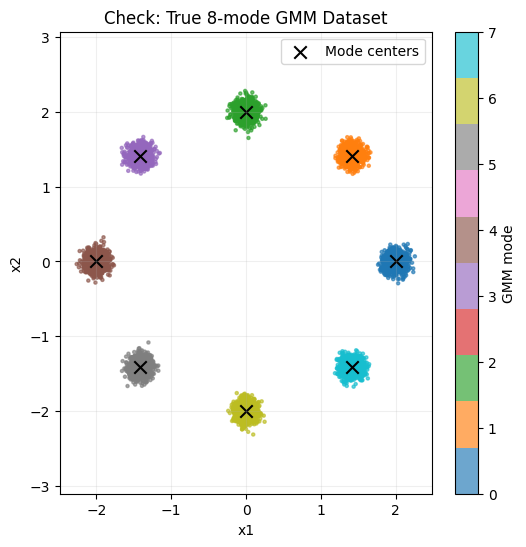

In [ ]:
plt.figure(figsize=(6,6))

scatter = plt.scatter(
    gmm_X[:,0],
    gmm_X[:,1],
    c=gmm_labels,
    s=5,
    alpha=0.65,
    cmap="tab10"
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    c="black",
    s=80,
    marker="x",
    label="Mode centers"
)

plt.title("Check: True 8-mode GMM Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.grid(alpha=0.2)
plt.legend()

cbar = plt.colorbar(scatter, ticks=np.arange(8))
cbar.set_label("GMM mode")


plt.show()


### Task 1.1: Variational Autoencoder (VAEs)

### Preparing DataLoaders for Training and Validation

We convert the GMM data into PyTorch tensors and wrap them in a TensorDataset. We then split the dataset into training and validation sets using an 80/20 split.

The DataLoader objects are used to efficiently feed mini-batches to the models during training and evaluation. The validation set helps us monitor whether the models generalize beyond the training samples.

In [ ]:
gmm_X_tensor = torch.tensor(gmm_X, dtype=torch.float32)
gmm_labels_tensor = torch.tensor(gmm_labels, dtype=torch.long)

full_dataset = TensorDataset(gmm_X_tensor, gmm_labels_tensor)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator = torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False
)

full_loader = DataLoader(
    full_dataset,
    batch_size=512,
    shuffle=False
)

print("Train size: ", len(train_dataset))
print("Validation size: ", len(val_dataset))

Train size:  6400
Validation size:  1600


### MLP Variational AutoEncoder Architecture

This cell defines the VAE used for the 2D GMM experiment. The encoder maps each 2D point to the parameters of a latent Gaussian distribution, namely the mean mu and log-variance logvar.

The reparameterization trick is used to sample a latent vector z while still allowing gradients to flow through the encoder. The decoder then maps z back to the original 2D space. This allows the VAE to learn a continuous latent representation of the GMM distribution.

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim=2, latent_dim=2, hidden_dim=256, num_hidden_layers=3):
        super().__init__()


        # Encoder

        encoder_layers = []

        # First layer: input_dim -> hidden_dim
        encoder_layers.append(nn.Linear(input_dim, hidden_dim))
        encoder_layers.append(nn.ReLU())

        # Additional hidden layers
        for _ in range(num_hidden_layers - 1):
            encoder_layers.append(nn.Linear(hidden_dim, hidden_dim))
            encoder_layers.append(nn.ReLU())

        self.encoder = nn.Sequential(*encoder_layers)

        # Latent distribution parameters
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)


        # Decoder

        decoder_layers = []

        # First layer: latent_dim -> hidden_dim
        decoder_layers.append(nn.Linear(latent_dim, hidden_dim))
        decoder_layers.append(nn.ReLU())

        # Additional hidden layers
        for _ in range(num_hidden_layers - 1):
            decoder_layers.append(nn.Linear(hidden_dim, hidden_dim))
            decoder_layers.append(nn.ReLU())

        # Final layer: hidden_dim -> input_dim
        decoder_layers.append(nn.Linear(hidden_dim, input_dim))

        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + std * eps
        return z

    def decode(self, z):
        x_recon = self.decoder(z)
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar, z

### VAE Loss Function: Negative ELBO

This cell implements the VAE objective as a negative ELBO. The reconstruction term measures how well the decoder reconstructs the original 2D point, assuming a Gaussian likelihood with fixed standard deviation recon_sigma.

The KL divergence regularizes the approximate posterior q(z|x) so that it stays close to the standard normal prior p(z) = N(0,I). The parameter beta controls the strengh of this regularization and helps balance reconstruction quality against latent space structure..


In [ ]:
def vae_loss(x, x_recon, mu, logvar, recon_sigma=0.05, beta=0.05):
    """
    Negative ELBO:
        loss = reconstruction negative log-likelihood + beta * KL

    Reconstruction term:
        assumes p(x|z) = Normal(decoder(z), recon_sigma^2 I)

    KL term:
        KL(q(z|x) || p(z)), where p(z) = N(0, I)
    """

    # Reconstruction negative log-likelihood
    recon_nll = 0.5 * (((x - x_recon) / recon_sigma) ** 2).sum(dim=1).mean()

    # KL divergence
    kl = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp(),
        dim=1
    ).mean()

    # Beta-VAE objective
    loss = recon_nll + beta * kl

    return loss, recon_nll, kl

### Evaluation Metrics for VAE Generated Samples

This cell defines a helper function to evaluate the quality of VAE-generated points. The model samples latent vectors from the standard normal prior, decodes them into 2D points, and compares them with the true GMM mode centers.

The metrics measure whether the generated samples cover all 8 modes, how many samples are close to a real mode, and how far generated points are on average from the nearest true center. These metrics help us select a VAE model that does not only minimize loss, but also generates samples that match the multi-modal structure of the data.

In [ ]:
def evaluate_generated_quality(
    model,
    centers,
    n_generated=4000,
    radius_threshold=0.35,
    min_points_per_mode=50
):
    """
    Evaluates how well generated samples cover the 8 GMM modes.

    Metrics:
        mode_coverage: how many of the 8 modes are covered
        valid_fraction: fraction of generated points close to a GMM center
        mean_nearest_center_dist: average distance to nearest GMM center

    Lower generated_score is better.
    """

    model.eval()

    with torch.no_grad():
        z = torch.randn(n_generated, 2).to(device)
        generated = model.decode(z).cpu().numpy()

    # Distance of each generated point to each GMM center
    dists = np.linalg.norm(
        generated[:, None, :] - centers[None, :, :],
        axis=2
    )

    nearest_mode = np.argmin(dists, axis=1)
    nearest_dist = np.min(dists, axis=1)

    # A generated point is considered valid if it is close to a real mode center
    valid = nearest_dist < radius_threshold

    counts_per_mode = np.bincount(
        nearest_mode[valid],
        minlength=8
    )

    mode_coverage = int(np.sum(counts_per_mode >= min_points_per_mode))
    valid_fraction = float(np.mean(valid))
    mean_nearest_center_dist = float(np.mean(nearest_dist))

    # Lower is better.
    # Missing modes are heavily penalized.
    generated_score = (
        100.0 * (8 - mode_coverage)
        + 10.0 * (1.0 - valid_fraction)
        + mean_nearest_center_dist
    )

    return {
        "mode_coverage": mode_coverage,
        "valid_fraction": valid_fraction,
        "mean_nearest_center_dist": mean_nearest_center_dist,
        "generated_score": generated_score,
        "counts_per_mode": counts_per_mode,
        "generated_samples": generated
    }

### Training One VAE Configuration

This cell defines the training procedure for one VAE hyperparameter configuration. For each trial, a new VAE is initialized, trained using the negative ELBO loss, and evaluated on the validation set.

The function also uses learning-rate scheduling, gradient clipping, and early stopping to make training more stable. After training, the best model from the trial is evaluated using generated-sample quality metrics, such as mode coverage and distance from the true GMM centers. These metrics are later used to select the best VAE configuration.


In [ ]:
def train_vae_config(config, trial_id=0):
    """
    Trains one VAE configuration and returns:
        result dictionary
        best model state
        training history
    """

    torch.manual_seed(SEED + trial_id)
    np.random.seed(SEED + trial_id)

    model = VAE(
        input_dim=2,
        latent_dim=2,
        hidden_dim=config["hidden_dim"],
        num_hidden_layers=config["num_hidden_layers"]
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr= config["lr"],
        weight_decay=config.get("weight_decay", 1e-4)
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=config.get("scheduler_factor", 0.5),
        patience=config.get("scheduler_patience", 3)
    )

    num_epochs = config["num_epochs"]
    eval_every = config["eval_every"]
    patience = config["patience"]
    min_delta = config["min_delta"]

    beta = config["beta"]
    recon_sigma = config["recon_sigma"]

    history = {
        "epoch": [],
        "train_loss": [],
        "train_recon": [],
        "train_kl": [],
        "val_loss": [],
        "val_recon": [],
        "val_kl": [],
        "lr": []
    }

    best_val_loss = float("inf")
    best_epoch = None
    best_train_loss = None
    best_val_recon = None
    best_val_kl = None
    best_model_state = None

    checks_without_improvement = 0

    for epoch in range(1, num_epochs + 1):

        # Training phase

        model.train()

        train_loss_sum = 0.0
        train_recon_sum = 0.0
        train_kl_sum = 0.0

        for batch_x, _ in train_loader:
            batch_x = batch_x.to(device)

            optimizer.zero_grad()

            x_recon, mu, logvar, z = model(batch_x)

            loss, recon_nll, kl = vae_loss(
                batch_x,
                x_recon,
                mu,
                logvar,
                recon_sigma=recon_sigma,
                beta=beta
            )

            loss.backward()

            # Helps stability
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0
            )

            optimizer.step()

            train_loss_sum += loss.item()
            train_recon_sum += recon_nll.item()
            train_kl_sum += kl.item()

        avg_train_loss = train_loss_sum / len(train_loader)
        avg_train_recon = train_recon_sum / len(train_loader)
        avg_train_kl = train_kl_sum / len(train_loader)


        # Validation phase

        if epoch % eval_every == 0 or epoch == 1:

            model.eval()

            val_loss_sum = 0.0
            val_recon_sum = 0.0
            val_kl_sum = 0.0

            with torch.no_grad():
                for batch_x, _ in val_loader:
                    batch_x = batch_x.to(device)

                    x_recon, mu, logvar, z = model(batch_x)

                    loss, recon_nll, kl = vae_loss(
                        batch_x,
                        x_recon,
                        mu,
                        logvar,
                        recon_sigma=recon_sigma,
                        beta=beta
                    )

                    val_loss_sum += loss.item()
                    val_recon_sum += recon_nll.item()
                    val_kl_sum += kl.item()

            avg_val_loss = val_loss_sum / len(val_loader)
            avg_val_recon = val_recon_sum / len(val_loader)
            avg_val_kl = val_kl_sum / len(val_loader)

            # Scheduler step based on validation loss
            scheduler.step(avg_val_loss)

            current_lr = optimizer.param_groups[0]["lr"]

            history["epoch"].append(epoch)

            history["train_loss"].append(avg_train_loss)
            history["train_recon"].append(avg_train_recon)
            history["train_kl"].append(avg_train_kl)

            history["val_loss"].append(avg_val_loss)
            history["val_recon"].append(avg_val_recon)
            history["val_kl"].append(avg_val_kl)

            history["lr"].append(current_lr)

            print(
                f"Trial {trial_id:02d} | "
                f"Epoch [{epoch:03d}/{num_epochs}] | "
                f"beta={beta} | sigma={recon_sigma} | lr={config['lr']} | "
                f"Val Loss: {avg_val_loss:.4f} | "
                f"Val Recon: {avg_val_recon:.4f} | "
                f"Val KL: {avg_val_kl:.4f}"
            )


            # Early stopping

            if avg_val_loss < best_val_loss - min_delta:
                best_val_loss = avg_val_loss
                best_epoch = epoch
                best_train_loss = avg_train_loss
                best_val_recon = avg_val_recon
                best_val_kl = avg_val_kl
                best_model_state = copy.deepcopy(model.state_dict())
                checks_without_improvement = 0
            else:
                checks_without_improvement += 1

            if checks_without_improvement >= patience:
                print(
                    f"Trial {trial_id:02d} early stopping at epoch {epoch}. "
                    f"Best val loss: {best_val_loss:.4f}"
                )
                break

    # Load best checkpoint before generated-quality evaluation
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    quality = evaluate_generated_quality(
        model=model,
        centers=centers,
        n_generated=4000,
        radius_threshold=0.35,
        min_points_per_mode=50
    )

    # Combined score.
    # Lower is better.
    selection_score = quality["generated_score"] + 0.01 * best_val_loss

    result = {
        "trial_id": trial_id,
        "hidden_dim": config["hidden_dim"],
        "num_hidden_layers": config["num_hidden_layers"],
        "lr": config["lr"],
        "weight_decay": config.get("weight_decay", 1e-4),
        "beta": config["beta"],
        "recon_sigma": config["recon_sigma"],
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_train_loss": best_train_loss,
        "best_val_recon": best_val_recon,
        "best_val_kl": best_val_kl,
        "mode_coverage": quality["mode_coverage"],
        "valid_fraction": quality["valid_fraction"],
        "mean_nearest_center_dist": quality["mean_nearest_center_dist"],
        "generated_score": quality["generated_score"],
        "selection_score": selection_score,
        "state_dict": copy.deepcopy(model.state_dict()),
        "history": history
    }

    return result

### Random Search for VAE Hyperparameters

In this cell, we define a hyperparameter search space for the VAE and randomly sample several configurations. Each trial trains a separate VAE with different values for architecture size, learning rate, KL weight `beta`, reconstruction variance, and weight decay.

Random search is used because the VAE performance depends strongly on the balance between reconstruction accuracy and latent regularization. By comparing multiple configurations, we can select the model that best captures the 8-mode GMM distribution.


In [ ]:
import pandas as pd
import time
import copy

param_space = {
    "hidden_dim": [128, 256],
    "num_hidden_layers": [2, 3, 4],
    "lr": [1e-3, 5e-4, 3e-4],
    "beta": [0.05, 0.10, 0.20, 0.50, 1.00],
    "recon_sigma": [0.05, 0.08, 0.10],
    "weight_decay": [0.0, 1e-5, 1e-4]
}

def sample_config(rng):
    return {
        "hidden_dim": int(rng.choice(param_space["hidden_dim"])),
        "num_hidden_layers": int(rng.choice(param_space["num_hidden_layers"])),
        "lr": float(rng.choice(param_space["lr"])),
        "beta": float(rng.choice(param_space["beta"])),
        "recon_sigma": float(rng.choice(param_space["recon_sigma"])),
        "weight_decay": float(rng.choice(param_space["weight_decay"])),
        "num_epochs": 300,
        "eval_every": 25,
        "patience": 4,
        "min_delta": 1e-4,
        "scheduler_factor": 0.5,
        "scheduler_patience": 2
    }


n_trials = 8

rng = np.random.default_rng(SEED)

all_results = []

start_time = time.time()

for trial_id in range(1, n_trials + 1):

    config = sample_config(rng)

    print("\n" + "=" * 80)
    print(f"Starting trial {trial_id}/{n_trials}")
    print("Config:", config)
    print("=" * 80)

    result = train_vae_config(
        config=config,
        trial_id=trial_id
    )

    all_results.append(result)

elapsed_time = time.time() - start_time

print("\nRandom search finished.")
print(f"Total time: {elapsed_time / 60:.2f} minutes")


Starting trial 1/8
Config: {'hidden_dim': 128, 'num_hidden_layers': 4, 'lr': 0.0005, 'beta': 0.2, 'recon_sigma': 0.08, 'weight_decay': 0.0001, 'num_epochs': 300, 'eval_every': 25, 'patience': 4, 'min_delta': 0.0001, 'scheduler_factor': 0.5, 'scheduler_patience': 2}
Trial 01 | Epoch [001/300] | beta=0.2 | sigma=0.08 | lr=0.0005 | Val Loss: 263.5429 | Val Recon: 263.3338 | Val KL: 1.0459
Trial 01 | Epoch [025/300] | beta=0.2 | sigma=0.08 | lr=0.0005 | Val Loss: 1.6620 | Val Recon: 0.3096 | Val KL: 6.7616
Trial 01 | Epoch [050/300] | beta=0.2 | sigma=0.08 | lr=0.0005 | Val Loss: 1.6258 | Val Recon: 0.3349 | Val KL: 6.4543
Trial 01 | Epoch [075/300] | beta=0.2 | sigma=0.08 | lr=0.0005 | Val Loss: 1.5274 | Val Recon: 0.3007 | Val KL: 6.1334
Trial 01 | Epoch [100/300] | beta=0.2 | sigma=0.08 | lr=0.0005 | Val Loss: 1.3987 | Val Recon: 0.2483 | Val KL: 5.7518
Trial 01 | Epoch [125/300] | beta=0.2 | sigma=0.08 | lr=0.0005 | Val Loss: 1.3290 | Val Recon: 0.2444 | Val KL: 5.4228
Trial 01 | Epoc

### VAE Random Search Results Table

This cell summarizes the results from all VAE random-search trials in a table. Large objects such as model weights and training histories are removed so that only the relevant hyperparameters and evaluation metrics are displayed.

The table is sorted by the final `selection_score`, where lower values indicate better generated-sample quality and validation performance. This makes it easier to identify the best VAE configuration for the GMM task.


In [ ]:
results_table = pd.DataFrame([
    {
        key: value
        for key, value in result.items()
        if key not in ["state_dict", "history"]
    }
    for result in all_results
])

results_table = results_table.sort_values(
    by="selection_score",
    ascending=True
).reset_index(drop=True)

results_table[
    [
        "trial_id",
        "hidden_dim",
        "num_hidden_layers",
        "lr",
        "weight_decay",
        "beta",
        "recon_sigma",
        "best_epoch",
        "best_val_loss",
        "best_val_recon",
        "best_val_kl",
        "mode_coverage",
        "valid_fraction",
        "mean_nearest_center_dist",
        "selection_score"
    ]
]

,trial_id,hidden_dim,num_hidden_layers,lr,weight_decay,beta,recon_sigma,best_epoch,best_val_loss,best_val_recon,best_val_kl,mode_coverage,valid_fraction,mean_nearest_center_dist,selection_score
0,7,256,4,0.0010,0.00010,0.50,0.05,250,2.912963,0.528302,4.769321,8,0.86125,0.213748,1.630377
1,8,256,3,0.0010,0.00010,1.00,0.08,250,4.349344,0.774157,3.575187,8,0.85450,0.185581,1.684074
2,5,256,3,0.0005,0.00001,1.00,0.08,300,4.426833,1.092575,3.334258,8,0.85300,0.185871,1.700140
3,3,256,4,0.0003,0.00000,0.50,0.08,275,2.440697,0.476133,3.929130,8,0.84200,0.212844,1.817251
4,1,128,4,0.0005,0.00010,0.20,0.08,300,1.173471,0.207321,4.830752,8,0.75850,0.272346,2.699081
5,2,128,4,0.0010,0.00010,0.05,0.08,300,0.407213,0.097337,6.197518,8,0.71400,0.293180,3.157252
6,6,128,2,0.0010,0.00000,0.20,0.10,250,1.114629,0.224362,4.451335,8,0.65025,0.329694,3.838340
7,4,256,3,0.0005,0.00010,0.10,0.05,275,0.867653,0.205930,6.617222,8,0.57300,0.379702,4.658378


### Selecting the Best VAE Trial

This cell selects the best VAE configuration from the random search results. The best trial is chosen as the one with the lowest `selection_score`, which combines generated-sample quality with validation performance.

After selecting the best trial, we print its hyperparameters and main evaluation metrics. This allows us to verify that the chosen model both covers the GMM modes and achieves reasonable validation loss, reconstruction error, and KL divergence.


In [ ]:
best_trial_id = int(results_table.loc[0, "trial_id"])

best_result = None

for result in all_results:
    if result["trial_id"] == best_trial_id:
        best_result = result
        break

print("Best trial:", best_result["trial_id"])
print("Best hyperparameters:")
print("hidden_dim:", best_result["hidden_dim"])
print("lr:", best_result["lr"])
print("beta:", best_result["beta"])
print("recon_sigma:", best_result["recon_sigma"])

print("\nBest scores:")
print("Best epoch:", best_result["best_epoch"])
print("Best validation loss:", best_result["best_val_loss"])
print("Best validation reconstruction:", best_result["best_val_recon"])
print("Best validation KL:", best_result["best_val_kl"])
print("Mode coverage:", best_result["mode_coverage"], "/ 8")
print("Valid fraction:", best_result["valid_fraction"])
print("Mean nearest center distance:", best_result["mean_nearest_center_dist"])
print("Selection score:", best_result["selection_score"])

Best trial: 7
Best hyperparameters:
hidden_dim: 256
lr: 0.001
beta: 0.5
recon_sigma: 0.05

Best scores:
Best epoch: 250
Best validation loss: 2.9129626410348073
Best validation reconstruction: 0.5283019244670868
Best validation KL: 4.769321441650391
Mode coverage: 8 / 8
Valid fraction: 0.86125
Mean nearest center distance: 0.2137475162744522
Selection score: 1.6303771426848006


### Loading the Best VAE Model

This cell reconstructs the VAE architecture using the hyperparameters of the selected best trial. We then load the saved model weights from that trial and switch the model to evaluation mode.

This gives us the final trained VAE model that will be used for generating 2D samples and visualizing the learned latent space.


In [ ]:
best_model = VAE(
    input_dim=2,
    latent_dim=2,
    hidden_dim=best_result["hidden_dim"],
    num_hidden_layers=best_result["num_hidden_layers"]
).to(device)

best_model.load_state_dict(best_result["state_dict"])
best_model.eval()

model = best_model

print("Best model loaded successfully.")
print("hidden_dim:", best_result["hidden_dim"])
print("num_hidden_layers:", best_result["num_hidden_layers"])
print("beta:", best_result["beta"])
print("recon_sigma:", best_result["recon_sigma"])

Best model loaded successfully.
hidden_dim: 256
num_hidden_layers: 4
beta: 0.5
recon_sigma: 0.05


### VAE Training Curves

This cell plots the training history of the selected VAE model. We visualize the total training loss, validation loss, reconstruction loss, and KL divergence across epochs.

These curves help us inspect whether the model trained stably and whether the loss components behaved as expected. The reconstruction term shows how well the decoder learns to reproduce the data, while the KL term shows the strength of the latent-space regularization.

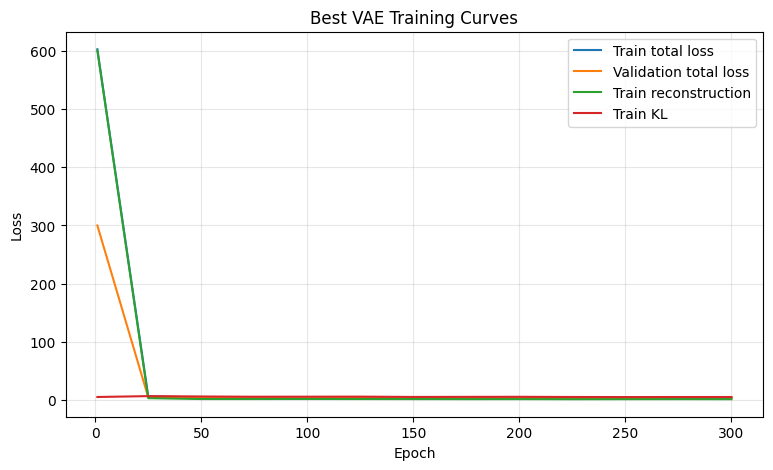

In [ ]:
best_history = best_result["history"]

plt.figure(figsize=(9, 5))

plt.plot(best_history["epoch"], best_history["train_loss"], label="Train total loss")
plt.plot(best_history["epoch"], best_history["val_loss"], label="Validation total loss")
plt.plot(best_history["epoch"], best_history["train_recon"], label="Train reconstruction")
plt.plot(best_history["epoch"], best_history["train_kl"], label="Train KL")

plt.title("Best VAE Training Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### VAE Generated Samples vs True GMM Data

This cell samples latent vectors from the standard normal prior and decodes them into 2D points using the trained VAE decoder. The generated points are then plotted together with the true GMM samples.

This comparison allows us to visually evaluate whether the VAE has learned the overall 8-mode ring structure of the data. It also shows whether the generated distribution covers all modes or produces overly smooth samples between the true clusters.

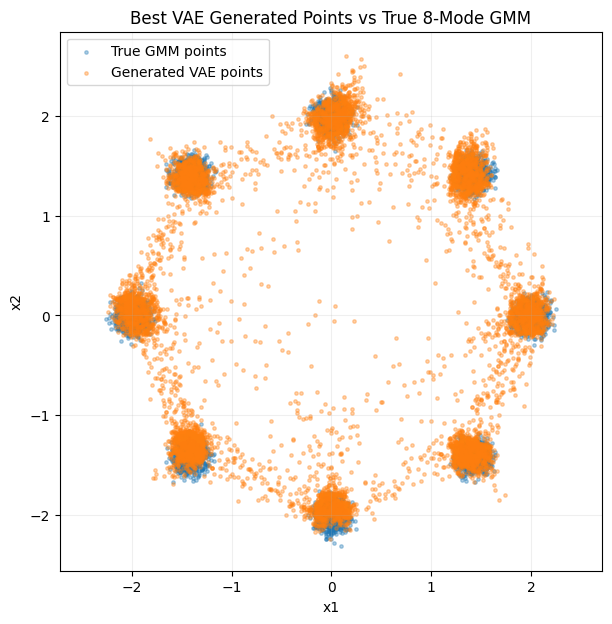

In [ ]:
model.eval()

n_generated = 8000

with torch.no_grad():
    z_sample = torch.randn(n_generated, 2).to(device)
    gmm_X_generated = model.decode(z_sample).cpu().numpy()

plt.figure(figsize=(7, 7))

plt.scatter(
    gmm_X[:, 0],
    gmm_X[:, 1],
    s=6,
    alpha=0.35,
    label="True GMM points"
)

plt.scatter(
    gmm_X_generated[:, 0],
    gmm_X_generated[:, 1],
    s=6,
    alpha=0.35,
    label="Generated VAE points"
)

plt.title("Best VAE Generated Points vs True 8-Mode GMM")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Visualizing the Learned VAE Latent Space

This cell encodes all GMM data points into the latent space and plots the mean latent representation mu for each sample. The points are colored according to their true GMM mode labels.

This visualization helps us understand how the VAE organizes the data in latent space. If the model has learned a meanigful representation, points from different modes should occupy different regions, while still forming a continuous latent structure.

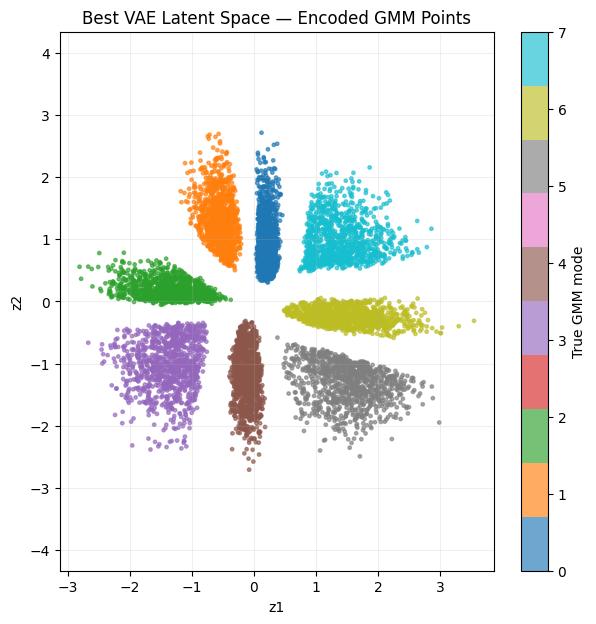

In [ ]:
model.eval()

all_mu = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_labels in full_loader:
        batch_x = batch_x.to(device)

        mu, logvar = model.encode(batch_x)

        all_mu.append(mu.cpu().numpy())
        all_labels.append(batch_labels.numpy())

latent_mu = np.vstack(all_mu)
latent_labels = np.concatenate(all_labels)

plt.figure(figsize=(7, 7))

scatter = plt.scatter(
    latent_mu[:, 0],
    latent_mu[:, 1],
    c=latent_labels,
    s=6,
    alpha=0.65,
    cmap="tab10"
)

plt.title("Best VAE Latent Space — Encoded GMM Points")
plt.xlabel("z1")
plt.ylabel("z2")
plt.axis("equal")
plt.grid(alpha=0.2)

cbar = plt.colorbar(scatter, ticks=np.arange(8))
cbar.set_label("True GMM mode")

plt.show()

### Creating the Best VAE Checkpoint

This cell creates a checkpoint for the selected best VAE model. The checkpoint stores the trained model weights, the architecture configuration, the best hyperparameters, the evaluation scores, and the training history.

Saving all this information is useful because it allows us to reload the exact same model later without repeating the random search or retraining process.


In [ ]:
import os
import torch

# Make sure this is the final selected/best VAE model
model = best_model.to(device)
model.eval()

checkpoint = {
    "model_state_dict": model.state_dict(),

    "model_config": {
        "input_dim": 2,
        "latent_dim": 2,
        "hidden_dim": best_result["hidden_dim"],
        "num_hidden_layers": best_result["num_hidden_layers"]
    },

    "best_hyperparameters": {
        "hidden_dim": best_result["hidden_dim"],
        "num_hidden_layers": best_result["num_hidden_layers"],
        "lr": best_result["lr"],
        "beta": best_result["beta"],
        "recon_sigma": best_result["recon_sigma"]
    },

    "best_scores": {
        "best_epoch": best_result["best_epoch"],
        "best_val_loss": best_result["best_val_loss"],
        "best_val_recon": best_result["best_val_recon"],
        "best_val_kl": best_result["best_val_kl"],
        "mode_coverage": best_result["mode_coverage"],
        "valid_fraction": best_result["valid_fraction"],
        "mean_nearest_center_dist": best_result["mean_nearest_center_dist"],
        "selection_score": best_result["selection_score"]
    },

    "history": best_result["history"]
}

print("Checkpoint created successfully.")
print("Model config:", checkpoint["model_config"])
print("Best hyperparameters:", checkpoint["best_hyperparameters"])
print("Best scores:", checkpoint["best_scores"])

Checkpoint created successfully.
Model config: {'input_dim': 2, 'latent_dim': 2, 'hidden_dim': 256, 'num_hidden_layers': 4}
Best hyperparameters: {'hidden_dim': 256, 'num_hidden_layers': 4, 'lr': 0.001, 'beta': 0.5, 'recon_sigma': 0.05}
Best scores: {'best_epoch': 250, 'best_val_loss': 2.9129626410348073, 'best_val_recon': 0.5283019244670868, 'best_val_kl': 4.769321441650391, 'mode_coverage': 8, 'valid_fraction': 0.86125, 'mean_nearest_center_dist': 0.2137475162744522, 'selection_score': 1.6303771426848006}


### Checkpoint Sanity Check

This cell tests whether the VAE checkpoint can be saved and loaded correctly. Instead of writing to disk immediately, we first serialize the checkpoint in memory and reload it.

This step helps verify that the checkpoint contains all required information, such as the model configuration, hyperparameters, scores, and training history, before saving it permanently to Google Drive.


In [ ]:
import io

# Sanity check: serialize and reload checkpoint in memory
buffer = io.BytesIO()
torch.save(checkpoint, buffer)
buffer.seek(0)

loaded_checkpoint = torch.load(
    buffer,
    map_location=device,
    weights_only=False
)

print("Checkpoint loaded successfully from memory.")
print("Model config:", loaded_checkpoint["model_config"])
print("Best hyperparameters:", loaded_checkpoint["best_hyperparameters"])
print("Best scores:", loaded_checkpoint["best_scores"])

# Keep the validated checkpoint for saving
checkpoint = loaded_checkpoint

Checkpoint loaded successfully from memory.
Model config: {'input_dim': 2, 'latent_dim': 2, 'hidden_dim': 256, 'num_hidden_layers': 4}
Best hyperparameters: {'hidden_dim': 256, 'num_hidden_layers': 4, 'lr': 0.001, 'beta': 0.5, 'recon_sigma': 0.05}
Best scores: {'best_epoch': 250, 'best_val_loss': 2.9129626410348073, 'best_val_recon': 0.5283019244670868, 'best_val_kl': 4.769321441650391, 'mode_coverage': 8, 'valid_fraction': 0.86125, 'mean_nearest_center_dist': 0.2137475162744522, 'selection_score': 1.6303771426848006}


### Saving the Best VAE Checkpoint to Google Drive

This cell mounts Google Drive and saves the validated VAE checkpoint as a `.pt` file. The checkpoint is stored permanently so that the best VAE model can be reloaded later without repeating the random search and training process.

This is especially useful for keeping the final selected model reproducible and available for later evaluation or visualization.


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

drive_save_dir = "/content/drive/MyDrive/vae_task_1_1"
os.makedirs(drive_save_dir, exist_ok=True)

vae_checkpoint_path = os.path.join(
    drive_save_dir,
    "best_vae_gmm_task_1_1.pt"
)

torch.save(
    checkpoint,
    vae_checkpoint_path
)

print("Saved best VAE model to Google Drive.")
print("Checkpoint path:", vae_checkpoint_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved best VAE model to Google Drive.
Checkpoint path: /content/drive/MyDrive/vae_task_1_1/best_vae_gmm_task_1_1.pt


### Loading the Saved VAE Checkpoint

This cell loads the saved VAE checkpoint from Google Drive and reconstructs the model using the stored architecture configuration. The trained weights are then loaded into the model and the model is set to evaluation mode.

This confirms that the saved checkpoint can be used independently of the original training process, making the final VAE model reproducible and ready for generation or further analysis.


In [ ]:

checkpoint = torch.load(
    vae_checkpoint_path,
    map_location=device,
    weights_only=False
)

model_config = checkpoint["model_config"]

loaded_vae = VAE(
    input_dim=model_config["input_dim"],
    latent_dim=model_config["latent_dim"],
    hidden_dim=model_config["hidden_dim"],
    num_hidden_layers=model_config["num_hidden_layers"]
).to(device)

loaded_vae.load_state_dict(checkpoint["model_state_dict"])
loaded_vae.eval()

model = loaded_vae

print("VAE model loaded and ready.")
print("Loaded model config:", checkpoint["model_config"])
print("Loaded hyperparameters:", checkpoint["best_hyperparameters"])
print("Loaded scores:", checkpoint["best_scores"])

VAE model loaded and ready.
Loaded model config: {'input_dim': 2, 'latent_dim': 2, 'hidden_dim': 256, 'num_hidden_layers': 4}
Loaded hyperparameters: {'hidden_dim': 256, 'num_hidden_layers': 4, 'lr': 0.001, 'beta': 0.5, 'recon_sigma': 0.05}
Loaded scores: {'best_epoch': 250, 'best_val_loss': 2.9129626410348073, 'best_val_recon': 0.5283019244670868, 'best_val_kl': 4.769321441650391, 'mode_coverage': 8, 'valid_fraction': 0.86125, 'mean_nearest_center_dist': 0.2137475162744522, 'selection_score': 1.6303771426848006}


### Task 1.2: Generative Adversarial Networks (GANs)

In [ ]:
# Imports, seed, device, same dataset as GMM


import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


def set_seed(seed=42):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)


set_seed(42)


device = torch.device("cpu")

print("Using device:", device)

Using device: cpu


### Preparing the GMM Dataset for GAN Training

This cell recreates the same 8-mode GMM dataset for the GAN experiment. The points are arranged on a ring with 8 Gaussian modes, matching the dataset used in the VAE task.

The data is converted into a PyTorch tensor and loaded with a `DataLoader` so that the GAN can train on mini-batches. The GAN will try to learn this distribution by training a generator to produce similar 2D samples and a discriminator to distinguish real from generated points.


In [ ]:
# Same 8-mode GMM

n_modes = 8
n_per_mode = 1000
radius = 2.0
std = 0.08

angles = np.linspace(0, 2 * np.pi, n_modes, endpoint=False)

centers = np.stack(
    [
        radius * np.cos(angles),
        radius * np.sin(angles)
    ],
    axis=1
).astype(np.float32)


X_np = []

for center in centers:
  points = center + std * np.random.randn(n_per_mode,2).astype(np.float32)
  X_np.append(points)

X_np = np.vstack(X_np)
np.random.shuffle(X_np)

X_tensor = torch.tensor(X_np, dtype=torch.float32)

batch_size = 256

dataset = TensorDataset(X_tensor)

loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

print("Dataset shape: ", X_np.shape)

Dataset shape:  (8000, 2)


### Visualizing the Real GMM Data for the GAN Task

This cell plots the real 8-mode GMM dataset together with the true mode centers. It gives a clear visual reference for the target distribution that the GAN must learn.

Later, we will compare the generator’s samples with this plot to see whether the GAN captures the ring structure and all 8 modes of the data.


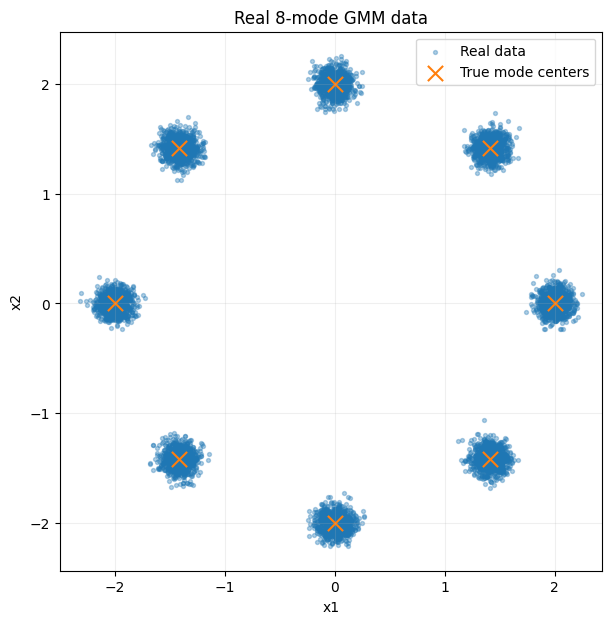

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(
    X_np[:,0],
    X_np[:,1],
    s=8,
    alpha=0.35,
    label="Real data"
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    marker="x",
    s=120,
    label="True mode centers"
)

plt.title("Real 8-mode GMM data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

### MLP Generator and Discriminator

This cell defines the two neural networks used in the GAN. The generator takes random latent noise as input and maps it to 2D points, trying to imitate samples from the real GMM distribution.

The distriminator takes a 2D point and outputs the probability that the point is real rather than generated. During training, the generator and discriminator are optimized against each other, which allows the generator to gradually learn the target data distribution.

In [ ]:
class Generator(nn.Module):
    def __init__(
        self,
        latent_dim=2,
        hidden_dim=128,
        output_dim=2,
        num_hidden_layers=3
    ):
        super().__init__()

        self.latent_dim = latent_dim

        layers = []

        layers.append(nn.Linear(latent_dim, hidden_dim))
        layers.append(nn.LeakyReLU(0.2))

        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.LeakyReLU(0.2))

        layers.append(nn.Linear(hidden_dim, output_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(
        self,
        input_dim=2,
        hidden_dim=128,
        dropout_rate=0.2,
        num_hidden_layers=3
    ):
        super().__init__()

        layers = []

        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.LeakyReLU(0.2))
        layers.append(nn.Dropout(dropout_rate))

        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.LeakyReLU(0.2))
            layers.append(nn.Dropout(dropout_rate))

        layers.append(nn.Linear(hidden_dim, 1))
        layers.append(nn.Sigmoid())

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

### GAN Sampling and Evaluation Utilities

This cell defines helper functions for evaluating the GAN. We first sample generated points from the generator and then estimate how many of the 8 GMM modes are covered by the generated distribution.

The evaluation metrics include mode coverage, mode balance, and distance from the true mode centers. These are important because GANs can suffer from mode collapse, whether the generator produces realistic samples from only a few modes instead of learning the full distribution. The plotting function is used to visually compare generated samples with the real GMM data.

In [ ]:
@torch.no_grad()
def sample_generator(G, n_samples=5000):
    G.eval()

    z = torch.randn(
        n_samples,
        G.latent_dim,
        device=device
    )

    generated = G(z)

    return generated.cpu().numpy()


def estimate_mode_coverage(samples, centers, threshold_fraction=0.01):
    distances = np.linalg.norm(
        samples[:, None, :] - centers[None, :, :],
        axis=2
    )

    nearest_modes = np.argmin(
        distances,
        axis=1
    )

    counts = np.bincount(
        nearest_modes,
        minlength=len(centers)
    )

    fractions = counts / counts.sum()

    active_modes = int(
        np.sum(fractions >= threshold_fraction)
    )

    return active_modes, counts, fractions


def evaluate_gan_quality(
    G,
    centers,
    n_samples=5000,
    threshold_fraction=0.01
):
    samples = sample_generator(
        G,
        n_samples=n_samples
    )

    distances = np.linalg.norm(
        samples[:, None, :] - centers[None, :, :],
        axis=2
    )

    nearest_modes = np.argmin(
        distances,
        axis=1
    )

    counts = np.bincount(
        nearest_modes,
        minlength=len(centers)
    )

    fractions = counts / counts.sum()

    active_modes = int(
        np.sum(fractions >= threshold_fraction)
    )

    uniform_fraction = np.ones(len(centers)) / len(centers)

    balance_error = np.mean(
        np.abs(fractions - uniform_fraction)
    )

    mean_nearest_distance = np.mean(
        np.min(distances, axis=1)
    )

    return {
        "samples": samples,
        "active_modes": active_modes,
        "counts": counts,
        "fractions": fractions,
        "balance_error": balance_error,
        "mean_nearest_distance": mean_nearest_distance
    }


def gan_quality_score(metrics):
    """
    Higher score is better.

    Priority:
    1. More active modes
    2. Better mode balance
    3. Smaller distance from true mode centers
    """

    score = (
        metrics["active_modes"]
        - metrics["balance_error"]
        - 0.1 * metrics["mean_nearest_distance"]
    )

    return score


def plot_generated_points(samples, title, centers, real_data=None):
    plt.figure(figsize=(6, 6))

    if real_data is not None:
        idx = np.random.choice(
            len(real_data),
            size=min(2000, len(real_data)),
            replace=False
        )

        plt.scatter(
            real_data[idx, 0],
            real_data[idx, 1],
            s=8,
            alpha=0.15,
            label="Real data"
        )

    plt.scatter(
        samples[:, 0],
        samples[:, 1],
        s=8,
        alpha=0.50,
        label="Generated samples"
    )

    plt.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="x",
        s=120,
        label="True mode centers"
    )

    plt.title(title)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.axis("equal")
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()

### GAN Training Procedure

This cell defines the training loop for one GAN configuration. For each batch, the discriminator is first trained to distinguish real GMM points from generated points, and then the generator is trained to produce samples that fool the discriminator.

The training uses the standard minimax GAN objective. To improve stability, the code also includes AdamW optimizers, learning-rate scheduling, periodic sample-quality evaluation, and early stopping. The best generator and discriminator are selected based on mode coverage, mode balance, and distance from the true GMM centers.


In [ ]:
# GAN training with AdamW, scheduler, and early stopping

def train_gan(
    loader,
    centers,
    latent_dim=2,
    hidden_dim=128,
    num_hidden_layers=3,
    lr_G=2e-4,
    lr_D=1e-4,
    weight_decay=1e-5,
    dropout_rate=0.2,
    epochs=500,
    seed=42,
    print_every=100,
    use_scheduler=True,
    use_early_stopping=True,
    check_every=100,
    patience=5
):
    set_seed(seed)

    G = Generator(
        latent_dim=latent_dim,
        hidden_dim=hidden_dim,
        output_dim=2,
        num_hidden_layers=num_hidden_layers
    ).to(device)

    D = Discriminator(
        input_dim=2,
        hidden_dim=hidden_dim,
        dropout_rate=dropout_rate,
        num_hidden_layers=num_hidden_layers
    ).to(device)

    optimizer_G = optim.AdamW(
        G.parameters(),
        lr=lr_G,
        weight_decay=weight_decay,
        betas=(0.5, 0.999)
    )

    optimizer_D = optim.AdamW(
        D.parameters(),
        lr=lr_D,
        weight_decay=weight_decay,
        betas=(0.5, 0.999)
    )

    if use_scheduler:
        scheduler_G = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer_G,
            mode="max",
            factor=0.5,
            patience=2,
            min_lr=1e-5
        )

        scheduler_D = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer_D,
            mode="max",
            factor=0.5,
            patience=2,
            min_lr=1e-5
        )
    else:
        scheduler_G = None
        scheduler_D = None

    eps = 1e-7 # numerical stability, prevent log(0)

    history = {
        "D_loss": [],
        "G_loss": [],
        "quality_score": [],
        "active_modes": []
    }

    best_score = -np.inf
    best_state = None
    patience_counter = 0

    for epoch in range(1, epochs + 1):

        G.train()
        D.train()

        epoch_D_losses = []
        epoch_G_losses = []

        for (real_x,) in loader:

            real_x = real_x.to(device)
            current_batch_size = real_x.size(0)


            # Train Discriminator
            # max_D log D(x) + log(1 - D(G(z)))


            z = torch.randn(
                current_batch_size,
                latent_dim,
                device=device
            )

            fake_x = G(z).detach()

            D_real = D(real_x)
            D_fake = D(fake_x)

            D_loss = -(
                torch.log(D_real + eps).mean()
                +
                torch.log(1 - D_fake + eps).mean()
            )

            optimizer_D.zero_grad() # clean old gradients
            D_loss.backward() # compute new gradients
            optimizer_D.step() # update weights


            # Train Generator
            # standard minimax: min_G log(1 - D(G(z)))


            z = torch.randn(
                current_batch_size,
                latent_dim,
                device=device
            )

            fake_x = G(z)
            D_fake_for_G = D(fake_x)

            G_loss = torch.log(1 - D_fake_for_G + eps).mean()

            optimizer_G.zero_grad()
            G_loss.backward()
            optimizer_G.step()

            epoch_D_losses.append(D_loss.item())
            epoch_G_losses.append(G_loss.item())

        mean_D_loss = np.mean(epoch_D_losses)
        mean_G_loss = np.mean(epoch_G_losses)

        history["D_loss"].append(mean_D_loss)
        history["G_loss"].append(mean_G_loss)


        # Evaluate sample quality every check_every epochs

        should_evaluate = (
            epoch % check_every == 0
            or epoch == epochs
        )

        if should_evaluate:

            metrics = evaluate_gan_quality(
                G,
                centers,
                n_samples=5000,
                threshold_fraction=0.01
            )

            score = gan_quality_score(metrics)

            history["quality_score"].append(score)
            history["active_modes"].append(metrics["active_modes"])

            if use_scheduler:
                scheduler_G.step(score)
                scheduler_D.step(score)

            if score > best_score:

                best_score = score
                patience_counter = 0

                clean_metrics = {
                    "active_modes": metrics["active_modes"],
                    "counts": metrics["counts"],
                    "fractions": metrics["fractions"],
                    "balance_error": metrics["balance_error"],
                    "mean_nearest_distance": metrics["mean_nearest_distance"]
                }

                best_state = {
                    "G": {
                        k: v.detach().cpu().clone()
                        for k, v in G.state_dict().items()
                    },
                    "D": {
                        k: v.detach().cpu().clone()
                        for k, v in D.state_dict().items()
                    },
                    "metrics": clean_metrics,
                    "epoch": epoch
                }

            else:
                patience_counter += 1

            print(
                f"Epoch [{epoch:4d}/{epochs}] "
                f"D_loss: {mean_D_loss:.4f} | "
                f"G_loss: {mean_G_loss:.4f} | "
                f"modes: {metrics['active_modes']}/8 | "
                f"score: {score:.4f}"
            )

            if use_early_stopping and patience_counter >= patience:
                print(
                    f"Early stopping at epoch {epoch}. "
                    f"Best epoch: {best_state['epoch']} | "
                    f"Best score: {best_score:.4f}"
                )
                break

        elif print_every and epoch % print_every == 0:

            print(
                f"Epoch [{epoch:4d}/{epochs}] "
                f"D_loss: {mean_D_loss:.4f} | "
                f"G_loss: {mean_G_loss:.4f}"
            )


    # Load best model found during training

    if best_state is not None:

        G.load_state_dict(
            {
                k: v.to(device)
                for k, v in best_state["G"].items()
            }
        )

        D.load_state_dict(
            {
                k: v.to(device)
                for k, v in best_state["D"].items()
            }
        )

        history["best_epoch"] = best_state["epoch"]
        history["best_metrics"] = best_state["metrics"]
        history["best_score"] = best_score

    G.eval()
    D.eval()

    return G, D, history

### GAN Model Selection Criterion

This cell defines the rule used to compare GAN models during random search. Since GAN losses alone are not always reliable indicators of sample quality, we select the best model using generated-sample metrics.

The selection prioritizes covering more GMM modes, then producing a more balanced distribution across modes, and finally generating samples closer to the true mode centers. This is important because a GAN may have reasonable losses while still suffering from mode collapse.


In [ ]:
# Random search utility for GAN model selection

import os
import pandas as pd


def is_better_gan(current_metrics, best_metrics):
    """
    Select the better GAN.

    Priority:
    1. More active modes
    2. Lower balance error
    3. Lower mean nearest-center distance
    """

    if best_metrics is None:
        return True

    if current_metrics["active_modes"] > best_metrics["active_modes"]:
        return True

    if current_metrics["active_modes"] < best_metrics["active_modes"]:
        return False

    if current_metrics["balance_error"] < best_metrics["balance_error"]:
        return True

    if current_metrics["balance_error"] > best_metrics["balance_error"]:
        return False

    if current_metrics["mean_nearest_distance"] < best_metrics["mean_nearest_distance"]:
        return True

    return False

### Random Search and Checkpointing for the GAN

This cell performs random search over several GAN hyperparameter configurations. For each trial, a new generator and discriminator are trained and then evaluated using mode coverage, balance error, and mean distance from the true GMM centers.

Whenever a better GAN is found, its generator and discriminator weights are saved as a checkpoint. The results from all trials are also stored in a table, so that we can compare configurations and reload the best GAN without repeating the random search.


In [ ]:
import os
import copy
import pandas as pd

random_search_trials = 5
tuning_epochs = 500

# Use the same directory for saving and loading GAN checkpoints
save_dir = drive_save_dir if "drive_save_dir" in globals() else "./saved_models"
os.makedirs(save_dir, exist_ok=True)

gan_checkpoint_path = os.path.join(
    save_dir,
    "best_gan_task_1_2.pt"
)

gan_results_path = os.path.join(
    save_dir,
    "gan_random_search_results_task_1_2.csv"
)

best_G = None
best_D = None
best_history = None
best_config = None
best_metrics = None

all_results = []

set_seed(42)

for trial in range(1, random_search_trials + 1):

    config = {
        "latent_dim": random.choice([2, 4, 8]),
        "hidden_dim": random.choice([64, 128, 256]),
        "num_hidden_layers": random.choice([2, 3, 4]),
        "lr_G": 10 ** np.random.uniform(np.log10(1e-4), np.log10(1e-3)),
        "lr_D": 10 ** np.random.uniform(np.log10(5e-5), np.log10(7e-4)),
        "weight_decay": random.choice([0.0, 1e-5, 1e-4]),
        "dropout_rate": random.choice([0.1, 0.2, 0.3, 0.4]),
        "epochs": tuning_epochs,
        "seed": 100 + trial,
        "print_every": 100,
        "use_scheduler": True,
        "use_early_stopping": True,
        "check_every": 100,
        "patience": 5
    }

    print("=" * 70)
    print(f"Trial {trial}/{random_search_trials}")
    print(
        f"latent_dim={config['latent_dim']} | "
        f"hidden_dim={config['hidden_dim']} | "
        f"layers={config['num_hidden_layers']} | "
        f"lr_G={config['lr_G']:.6f} | "
        f"lr_D={config['lr_D']:.6f} | "
        f"wd={config['weight_decay']} | "
        f"dropout={config['dropout_rate']}"
    )

    G_trial, D_trial, history_trial = train_gan(
        loader,
        centers=centers,
        **config
    )

    metrics_trial = evaluate_gan_quality(
        G_trial,
        centers,
        n_samples=5000,
        threshold_fraction=0.01
    )

    active_modes = metrics_trial["active_modes"]
    balance_error = metrics_trial["balance_error"]
    mean_distance = metrics_trial["mean_nearest_distance"]
    fractions = metrics_trial["fractions"]

    print(
        f"Result: {active_modes}/8 modes | "
        f"balance_error={balance_error:.4f} | "
        f"mean_distance={mean_distance:.4f}"
    )
    print("Mode fractions:", np.round(fractions, 3))

    all_results.append({
        "trial": trial,
        **config,
        "best_epoch": history_trial.get("best_epoch", None),
        "best_score": history_trial.get("best_score", None),
        "active_modes": active_modes,
        "balance_error": balance_error,
        "mean_nearest_distance": mean_distance,
        "counts_per_mode": metrics_trial["counts"].tolist(),
        "fractions_per_mode": np.round(fractions, 4).tolist()
    })

    if is_better_gan(metrics_trial, best_metrics):

        best_G = G_trial
        best_D = D_trial
        best_history = history_trial
        best_config = config.copy()
        best_metrics = metrics_trial

        checkpoint = {
            "generator_state_dict": best_G.state_dict(),
            "discriminator_state_dict": best_D.state_dict(),
            "best_config": best_config.copy(),
            "best_metrics": {
                "active_modes": best_metrics["active_modes"],
                "counts": best_metrics["counts"],
                "fractions": best_metrics["fractions"],
                "balance_error": best_metrics["balance_error"],
                "mean_nearest_distance": best_metrics["mean_nearest_distance"]
            },
            "history": copy.deepcopy(best_history),
            "centers": centers
        }

        torch.save(
            checkpoint,
            gan_checkpoint_path
        )

        print("New best model saved.")
        print("Checkpoint path:", gan_checkpoint_path)


# Save random search results

results_df = pd.DataFrame(all_results)

results_df.to_csv(
    gan_results_path,
    index=False
)

print("=" * 70)
print("Random search completed.")

print("\nBest config:")
print(best_config)

print("\nBest metrics:")
print("Active modes:", best_metrics["active_modes"], "/8")
print("Counts:", best_metrics["counts"])
print("Fractions:", np.round(best_metrics["fractions"], 3))
print("Balance error:", round(best_metrics["balance_error"], 4))
print("Mean nearest distance:", round(best_metrics["mean_nearest_distance"], 4))

print("\nSaved best GAN checkpoint at:")
print(gan_checkpoint_path)

print("\nSaved random search results at:")
print(gan_results_path)

Trial 1/5
latent_dim=8 | hidden_dim=64 | layers=2 | lr_G=0.000237 | lr_D=0.000615 | wd=0.0001 | dropout=0.3
Epoch [ 100/500] D_loss: 1.3397 | G_loss: -0.6707 | modes: 8/8 | score: 7.9494
Epoch [ 200/500] D_loss: 1.3422 | G_loss: -0.6692 | modes: 8/8 | score: 7.9576
Epoch [ 300/500] D_loss: 1.3598 | G_loss: -0.6827 | modes: 8/8 | score: 7.9643
Epoch [ 400/500] D_loss: 1.3751 | G_loss: -0.6817 | modes: 8/8 | score: 7.9764
Epoch [ 500/500] D_loss: 1.3791 | G_loss: -0.6874 | modes: 8/8 | score: 7.9797
Result: 8/8 modes | balance_error=0.0064 | mean_distance=0.1858
Mode fractions: [0.122 0.118 0.126 0.142 0.128 0.117 0.13  0.118]
New best model saved.
Checkpoint path: /content/drive/MyDrive/vae_task_1_1/best_gan_task_1_2.pt
Trial 2/5
latent_dim=8 | hidden_dim=64 | layers=4 | lr_G=0.000328 | lr_D=0.000225 | wd=1e-05 | dropout=0.4
Epoch [ 100/500] D_loss: 1.3890 | G_loss: -0.7048 | modes: 8/8 | score: 7.9347
Epoch [ 200/500] D_loss: 1.3867 | G_loss: -0.6931 | modes: 8/8 | score: 7.9544
Epoch 

### Loading the Best GAN Checkpoint

This cell loads the saved checkpoint of the best GAN found during random search. The generator and discriminator architectures are reconstructed using the saved hyperparameters, and their trained weights are restored from the checkpoint.

After loading, both networks are set to evaluation mode. The loaded generator is then used in the following cells to produce and visualize generated samples from the learned GMM distribution.


In [ ]:
# Load best GAN checkpoint

checkpoint = torch.load(
    gan_checkpoint_path,
    map_location=device,
    weights_only=False
)

loaded_config = checkpoint["best_config"]

# Fallback only for older checkpoints
num_hidden_layers = loaded_config.get("num_hidden_layers", 3)

G_loaded = Generator(
    latent_dim=loaded_config["latent_dim"],
    hidden_dim=loaded_config["hidden_dim"],
    output_dim=2,
    num_hidden_layers=num_hidden_layers
).to(device)

D_loaded = Discriminator(
    input_dim=2,
    hidden_dim=loaded_config["hidden_dim"],
    dropout_rate=loaded_config["dropout_rate"],
    num_hidden_layers=num_hidden_layers
).to(device)

G_loaded.load_state_dict(
    checkpoint["generator_state_dict"]
)

D_loaded.load_state_dict(
    checkpoint["discriminator_state_dict"]
)

G_loaded.eval()
D_loaded.eval()

# Use these variables in the following cells
G_best = G_loaded
D_best = D_loaded

print("Best GAN loaded successfully.")

print("\nLoaded checkpoint path:")
print(gan_checkpoint_path)

print("\nLoaded config:")
print(loaded_config)

print("\nLoaded metrics:")
print(checkpoint["best_metrics"])

Best GAN loaded successfully.

Loaded checkpoint path:
/content/drive/MyDrive/vae_task_1_1/best_gan_task_1_2.pt

Loaded config:
{'latent_dim': 2, 'hidden_dim': 256, 'num_hidden_layers': 4, 'lr_G': 0.00039598759848971286, 'lr_D': 0.000297671699635593, 'weight_decay': 1e-05, 'dropout_rate': 0.2, 'epochs': 500, 'seed': 103, 'print_every': 100, 'use_scheduler': True, 'use_early_stopping': True, 'check_every': 100, 'patience': 5}

Loaded metrics:
{'active_modes': 8, 'counts': array([663, 618, 554, 620, 596, 659, 635, 655]), 'fractions': array([0.1326, 0.1236, 0.1108, 0.124 , 0.1192, 0.1318, 0.127 , 0.131 ]), 'balance_error': np.float64(0.005600000000000001), 'mean_nearest_distance': np.float32(0.107984155)}


### Evaluating Samples from the Loaded GAN

This cell generates new 2D samples from the loaded GAN generator and evaluates their mode coverage. The generated samples are assigned to the nearest true GMM mode center, and we compute how many of the 8 modes are represented.

This check confirms that the loaded checkpoint still produces the expected result and that the saved generator has not lost the ability to cover the GMM modes.


In [ ]:
# Generate samples from loaded GAN

loaded_samples = sample_generator(
    G_loaded,
    n_samples=5000
)

# Use centers from checkpoint if available, otherwise use global centers
loaded_centers = checkpoint.get("centers", centers)

active_modes_loaded, counts_loaded, fractions_loaded = estimate_mode_coverage(
    loaded_samples,
    loaded_centers,
    threshold_fraction=0.01
)

print("Loaded GAN mode coverage:", active_modes_loaded, "/8")
print("Counts per mode:", counts_loaded)
print("Fractions per mode:", np.round(fractions_loaded, 3))

Loaded GAN mode coverage: 8 /8
Counts per mode: [660 635 583 627 605 653 622 615]
Fractions per mode: [0.132 0.127 0.117 0.125 0.121 0.131 0.124 0.123]


### Visualizing the Best GAN Samples

This cell plots the samples generated by the best loaded GAN and compares them with the real GMM data and the true mode centers. This visual comparison helps us assess whether the generator has learned the overall ring structure and whether it produces samples around all 8 modes.

Together with the numerical mode-coverage metrics, this plot provides a clear qualitative evaluation of the GAN’s performance.


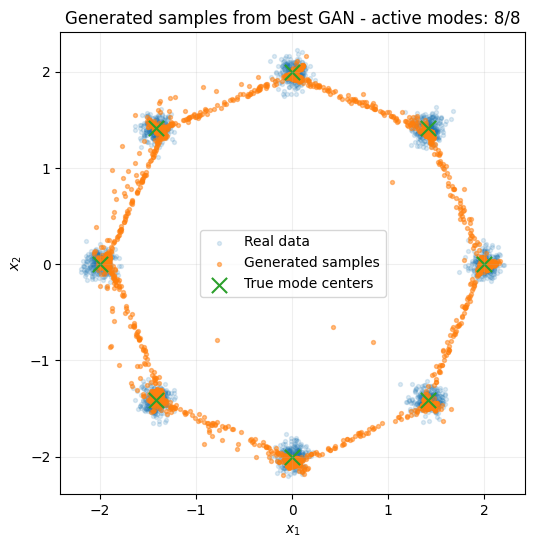

In [ ]:
# Plot generated points from best GAN

plot_generated_points(
    loaded_samples,
    title=f"Generated samples from best GAN - active modes: {active_modes_loaded}/8",
    centers=loaded_centers,
    real_data=X_np
)

### Training a GAN Example with Mode Collapse

This cell trains a specific GAN configuration that produced mode collapse during hyperparameter tuning. Mode collapse occurs when the generator learns to produce samples from only a few modes of the data distribution instead of covering all 8 GMM modes.




In [ ]:
collapse_config = {
    "latent_dim": 8,
    "hidden_dim": 128,
    "num_hidden_layers": 4,
    "lr_G": 0.000270,
    "lr_D": 0.000079,
    "weight_decay": 0.0001,
    "dropout_rate": 0.4,
    "epochs": 500,
    "seed": 104,
    "print_every": 100
}

G_collapse, D_collapse, history_collapse = train_gan(
    loader,
    centers,
    **collapse_config
)

Epoch [ 100/500] D_loss: 1.3657 | G_loss: -0.6766 | modes: 1/8 | score: 0.7125
Epoch [ 200/500] D_loss: 1.4355 | G_loss: -0.7946 | modes: 1/8 | score: 0.7461
Epoch [ 300/500] D_loss: 1.4572 | G_loss: -0.7476 | modes: 2/8 | score: 1.7146
Epoch [ 400/500] D_loss: 1.3337 | G_loss: -0.6575 | modes: 1/8 | score: 0.7389
Epoch [ 500/500] D_loss: 1.3827 | G_loss: -0.6502 | modes: 1/8 | score: 0.7618


### Measuring Mode Collapse

This cell generates samples from the collapsed GAN and measures how many GMM modes are covered. The generated points are assigned to the nearest true mode center, and the fraction of samples in each mode is reported.

If only a small number of modes are active, this confirms mode collapse. This numerical check supports the visual evidence and shows that the generator failed to learn the full multi-modal distribution.


In [ ]:
collapsed_samples = sample_generator(
    G_collapse,
    n_samples=5000
)

active_modes_collapse, counts_collapse, fractions_collapse = estimate_mode_coverage(
    collapsed_samples,
    centers,
    threshold_fraction=0.01
)

print("Collapsed GAN mode coverage:", active_modes_collapse, "/8")
print("Counts per mode:", counts_collapse)
print("Fractions per mode:", np.round(fractions_collapse, 3))

Collapsed GAN mode coverage: 2 /8
Counts per mode: [   0    0    0 4759  241    0    0    0]
Fractions per mode: [0.    0.    0.    0.952 0.048 0.    0.    0.   ]


### Visual Example of GAN Mode Collapse

This cell visualizes the samples produced by the collapsed GAN configuration. By comparing these samples with the real GMM data and the true mode centers, we can clearly see that the generator concentrates on only a small subset of the available modes.

This plot provides the qualitative evidence of mode collapse required by the assignment and highlights the instability of standard GAN training.


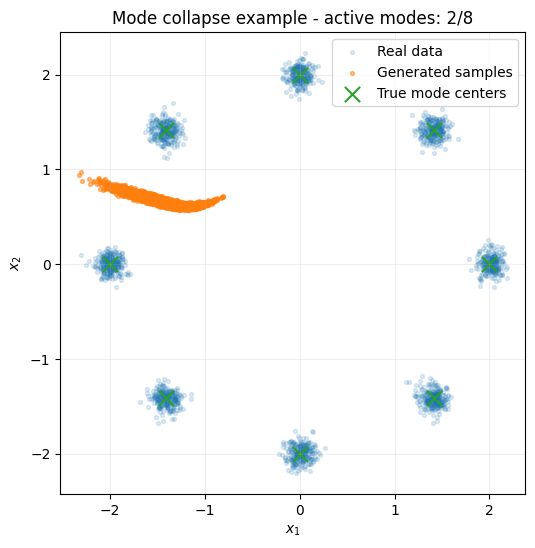

In [ ]:
plot_generated_points(
    collapsed_samples,
    title=f"Mode collapse example - active modes: {active_modes_collapse}/8",
    centers=centers,
    real_data=X_np
)

### Task 1.3: Denoising Diffusion Probabilistic Model (DDPM)

### Imports, device, seed

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
import copy
import random

In [ ]:
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cpu")

print("Using device:", device)

Using device: cpu


### Prepare GMM data

In [ ]:
# Use the same real GMM samples from Task 1.1 / Task 1.2

X_all = torch.tensor(gmm_X, dtype=torch.float32)

print("Dataset shape:", X_all.shape)

Dataset shape: torch.Size([8000, 2])


### Normalizing the GMM Data for DDPM Training

This cell normalizes the 2D GMM data to have approximately zero mean and unit standard deviation. This helps the DDPM train more stably, because the forward diffusion process assumes that the data scale is well controlled before noise is added.

After normalization, the dataset is split into training and validation sets and loaded into mini-batches. The printed mean and standard deviation confim that the normalized data is centered around 0 with standard deviation close to 1.

In [ ]:
x_mean = X_all.mean(dim=0, keepdim=True)
x_std = X_all.std(dim=0, keepdim=True)

X_all_norm = (X_all - x_mean) / x_std

dataset = TensorDataset(X_all_norm)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

batch_size = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False
)

print("Train size: ", train_size)
print("Validation size: ", val_size)
print("Normalized mean: ", X_all_norm.mean(dim=0))
print("Normalized std: ", X_all_norm.std(dim=0))

Train size:  6400
Validation size:  1600
Normalized mean:  tensor([-2.4557e-08,  1.0967e-08])
Normalized std:  tensor([1.0000, 1.0000])


### DDPM Forward Diffusion Schedule

This cell defines the forward noise schedule for the 2D DDPM experiment. We use `T = 100` diffusion steps, as required by the assignment, and linearly increase the noise variance from `beta_start` to `beta_end`.

The variables `alphas`, `alpha_bars`, and their square roots are precomputed because they are used repeatedly during both forward noising and reverse denoising. The final `alpha_bar` value indicates how much of the original signal remains after the full forward diffusion process.


In [ ]:
T = 100

beta_start = 1e-4
beta_end = 0.05

betas = torch.linspace(beta_start, beta_end, T).to(device)

alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

sqrt_alpha_bars = torch.sqrt(alpha_bars)
sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)

print("Number of diffusion steps T:", T)
print("beta_start:", beta_start)
print("beta_end:", beta_end)
print("alpha_bar at t=100:", alpha_bars[-1].item())

Number of diffusion steps T: 100
beta_start: 0.0001
beta_end: 0.05
alpha_bar at t=100: 0.07823432236909866


### Forward Noising Function

This cell implements the forward diffusion process `q(x_t | x_0)`. Given a clean 2D point `x_0`, a timestep `t`, and Gaussian noise, the function produces a noisy version `x_t`.

This is the training input for the DDPM. The model will later learn to predict the noise that was added to `x_0`, which is the simplified DDPM objective used in the assignment.


In [ ]:
def q_sample(x0, t, noise=None):
    """
    Create noisy samples x_t from clean samples x_0.

    Formula:
    x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * noise

    t contains values from 1 to T.
    """

    if noise is None:
        noise = torch.randn_like(x0)

    # Convert t from values 1...T to indices 0...T-1
    t_index = t - 1

    sqrt_ab = sqrt_alpha_bars[t_index].unsqueeze(1)
    sqrt_one_minus_ab = sqrt_one_minus_alpha_bars[t_index].unsqueeze(1)

    x_t = sqrt_ab * x0 + sqrt_one_minus_ab * noise

    return x_t, noise

### Sanity Check for the Forward Diffusion Function

This cell tests the `q_sample` function on a mini-batch of normalized GMM points. We randomly sample a timestep for each point and create the corresponding noisy samples.

The printed shapes confirm that the clean data, timesteps, noisy samples, and noise tensors are compatible. This check helps verify that the forward diffusion function works correctly before training the DDPM noise predictor.


In [ ]:
batch = next(iter(train_loader))
x0_batch = batch[0].to(device)

t_test = torch.randint(
    low=1,
    high=T + 1,
    size=(x0_batch.shape[0],),
    device=device
)

x_t_batch, noise_batch = q_sample(x0_batch, t_test)

print("x0 batch shape:", x0_batch.shape)
print("t batch shape:", t_test.shape)
print("x_t batch shape:", x_t_batch.shape)
print("noise batch shape:", noise_batch.shape)

x0 batch shape: torch.Size([256, 2])
t batch shape: torch.Size([256])
x_t batch shape: torch.Size([256, 2])
noise batch shape: torch.Size([256, 2])


### Sinusoidal Timestep Embedding

This cell defines a sinusoidal embedding layer for the diffusion timestep t. Instead of giving the timestep to the model as a single scalar, we convert it into a higher-dimensional vector using sine and cosine functions.

This helps the DDPM noise predictor understand which stage of the diffusion process each noisy sample belongs to. Since the amount of noise changes with t, timestep conditioning is essential for learning the denoising process.

In [ ]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, time_dim):
        super().__init__()
        self.time_dim = time_dim

    def forward(self, t):
        """
        Convert timestep t into a vector representation.

        Input:
        t shape: (batch_size,)

        Output:
        embedding shape: (batch_size, time_dim)
        """

        half_dim = self.time_dim // 2

        frequencies = torch.exp(
            -np.log(10000) * torch.arange(half_dim, device=t.device) / (half_dim - 1)
        )

        t = t.float().unsqueeze(1)

        angles = t * frequencies.unsqueeze(0)

        embedding = torch.cat(
            [torch.sin(angles), torch.cos(angles)],
            dim=1
        )

        return embedding

### MLP Noise Predictor for the 2D DDPM

This cell defines the neural network used by the DDPM to predict the noise added to each 2D point. The model receives both the noisy sample `x_t` and a sinusoidal embedding of the timestep `t`.

By conditioning on the timestep, the network learns how to denoise samples at different noise levels. Its output has the same dimension as the input data, because the simplified DDPM objective trains the model to predict the added 2D Gaussian noise.


In [ ]:
class NoisePredictorMLP(nn.Module):
    def __init__(
        self,
        x_dim=2,
        time_dim=32,
        hidden_dim=128,
        num_hidden_layers=2,
        dropout=0.1
    ):
        super().__init__()

        self.time_embedding = SinusoidalTimeEmbedding(time_dim)

        input_dim = x_dim + time_dim

        layers = []

        # First hidden layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.SiLU())
        layers.append(nn.Dropout(dropout))

        # Additional hidden layers
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.SiLU())
            layers.append(nn.Dropout(dropout))

        # Output layer: predicted 2D noise
        layers.append(nn.Linear(hidden_dim, x_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x_t, t):
        t_emb = self.time_embedding(t)

        model_input = torch.cat([x_t, t_emb], dim=1)

        predicted_noise = self.net(model_input)

        return predicted_noise

### Sanity Check for the DDPM Noise Predictor

This cell tests the `NoisePredictorMLP` on a noisy mini-batch from the forward diffusion process. The model receives the noisy samples `x_t` together with their corresponding timesteps `t`.

The printed output shape confirms that the network predicts one 2D noise vector for each input sample. This verifies that the model architecture is compatible with the simplified DDPM training objective.


In [ ]:
test_model = NoisePredictorMLP(
    x_dim=2,
    time_dim=32,
    hidden_dim=128,
    dropout=0.3
).to(device)

predicted_noise = test_model(x_t_batch, t_test)

print("Input x_t shape:", x_t_batch.shape)
print("Input t shape:", t_test.shape)
print("Predicted noise shape:", predicted_noise.shape)

Input x_t shape: torch.Size([256, 2])
Input t shape: torch.Size([256])
Predicted noise shape: torch.Size([256, 2])


### Simplified DDPM Training Loss

This cell defines the simplified DDPM loss function. For each clean 2D point `x_0`, we randomly sample a timestep `t`, add Gaussian noise using the forward diffusion process, and ask the model to predict the noise that was added.

The loss is the mean squared error between the true noise and the predicted noise. By minimizing this objective, the model learns how to denoise samples at different diffusion timesteps.


In [ ]:
def ddpm_loss(model, x0):
  x0 = x0.to(device)

  batch_size = x0.shape[0]

  # Sample a random timestep t for each point in the batch
  t = torch.randint(
      low=1,
      high=T+1,
      size=(batch_size,),
      device=device
  )

  # Sample true Gaussian noise epsilon
  noise = torch.randn_like(x0)

  # Create noisy sample x_t
  x_t, noise = q_sample(x0, t, noise)

  # Predict the added noise using the MLP
  predicted_noise = model(x_t, t)

  # Mean Squared Error between true noise and predicted noise
  loss = F.mse_loss(predicted_noise, noise)

  return loss

### Testing the DDPM Loss Function

This cell computes the DDPM loss on a single mini-batch using the test noise predictor model. This is a quick sanity check to confirm that the forward noising process, timestep conditioning, model prediction, and loss calculation all work together correctly.

A valid scalar loss value indicates that the DDPM training objective is implemented correctly and can be used in the full training loop.


In [ ]:
test_loss = ddpm_loss(test_model, x0_batch)

print("Test DDPM Loss:", test_loss.item())

Test DDPM Loss: 0.9701308012008667


### DDPM Training Loop

This cell defines the full training procedure for the 2D DDPM noise predictor. For each epoch, the model is trained to predict the Gaussian noise added to normalized GMM samples at randomly selected diffusion timesteps.

The training loop includes validation loss monitoring, learning-rate scheduling, gradient clipping, and early stopping. The best model is selected based on validation loss and restored at the end, so that later sampling uses the strongest checkpoint from training.


In [ ]:
def train_ddpm_model(config, train_loader, val_loader, max_epochs=250, patience=25):
    model = NoisePredictorMLP(
        x_dim=2,
        time_dim=config["time_dim"],
        hidden_dim=config["hidden_dim"],
        num_hidden_layers=config["num_hidden_layers"],
        dropout=config["dropout"]
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=config["scheduler_factor"],
        patience=config["scheduler_patience"],
        min_lr=config["min_lr"]
    )

    best_val_loss = float("inf")
    best_model_state = None
    best_epoch = 0
    patience_counter = 0

    train_losses = []
    val_losses = []
    learning_rates = []

    for epoch in range(1, max_epochs + 1):

        # Training phase

        model.train()
        total_train_loss = 0.0

        for batch in train_loader:
            x0 = batch[0].to(device)

            optimizer.zero_grad()

            loss = ddpm_loss(model, x0)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            total_train_loss += loss.item() * x0.size(0)

        avg_train_loss = total_train_loss / len(train_loader.dataset)


        # Validation phase

        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for batch in val_loader:
                x0 = batch[0].to(device)

                loss = ddpm_loss(model, x0)

                total_val_loss += loss.item() * x0.size(0)

        avg_val_loss = total_val_loss / len(val_loader.dataset)

        scheduler.step(avg_val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        learning_rates.append(current_lr)


        # Early stopping

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 25 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:03d} | "
                f"Train Loss: {avg_train_loss:.4f} | "
                f"Val Loss: {avg_val_loss:.4f} | "
                f"LR: {current_lr:.6f}"
            )

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_model_state)

    history = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "learning_rates": learning_rates,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch
    }

    return model, history

### Random Search for DDPM Hyperparameters

This cell performs random search over several DDPM hyperparameter configurations. Each trial trains a different noise predictor by varying the timestep embedding size, hidden dimension, number of layers, dropout, learning rate, weight decay, and scheduler patience.

The best model is selected using the lowest validation loss. This process helps identify a DDPM configuration that learns the denoising objective effectively while staying within the lightweight CPU constraints of Part 1.


In [ ]:
search_space = {
    "time_dim": [16, 32, 64],
    "hidden_dim": [64, 128, 256],
    "num_hidden_layers": [1, 2, 3],
    "dropout": [0.0, 0.1, 0.2],
    "lr": [1e-3, 5e-4, 3e-4],
    "weight_decay": [0.0, 1e-5, 1e-4],
    "scheduler_factor": [0.5],
    "scheduler_patience": [6, 8, 10],
    "min_lr": [1e-5]
}


def sample_ddpm_config():
    return {
        "time_dim": random.choice(search_space["time_dim"]),
        "hidden_dim": random.choice(search_space["hidden_dim"]),
        "num_hidden_layers": random.choice(search_space["num_hidden_layers"]),
        "dropout": random.choice(search_space["dropout"]),
        "lr": random.choice(search_space["lr"]),
        "weight_decay": random.choice(search_space["weight_decay"]),
        "scheduler_factor": random.choice(search_space["scheduler_factor"]),
        "scheduler_patience": random.choice(search_space["scheduler_patience"]),
        "min_lr": random.choice(search_space["min_lr"])
    }


n_trials = 5

all_results = []
best_ddpm_model = None
best_ddpm_history = None
best_ddpm_config = None
best_ddpm_val_loss = float("inf")

for trial in range(1, n_trials + 1):
    print("=" * 70)
    print(f"DDPM Random Search Trial {trial}/{n_trials}")

    config = sample_ddpm_config()

    print("Config:")
    for key, value in config.items():
        print(f"  {key}: {value}")

    model, history = train_ddpm_model(
        config=config,
        train_loader=train_loader,
        val_loader=val_loader,
        max_epochs=250,
        patience=25
    )

    result = {
        "trial": trial,
        "config": config,
        "best_val_loss": history["best_val_loss"],
        "best_epoch": history["best_epoch"]
    }

    all_results.append(result)

    print(
        f"Trial {trial} finished | "
        f"Best Val Loss: {history['best_val_loss']:.4f} | "
        f"Best Epoch: {history['best_epoch']}"
    )

    if history["best_val_loss"] < best_ddpm_val_loss:
        best_ddpm_val_loss = history["best_val_loss"]
        best_ddpm_model = model
        best_ddpm_history = history
        best_ddpm_config = config

print("=" * 70)
print("Best DDPM config:")
for key, value in best_ddpm_config.items():
    print(f"  {key}: {value}")

print("Best DDPM validation loss:", best_ddpm_val_loss)

DDPM Random Search Trial 1/5
Config:
  time_dim: 64
  hidden_dim: 64
  num_hidden_layers: 1
  dropout: 0.2
  lr: 0.0005
  weight_decay: 0.0
  scheduler_factor: 0.5
  scheduler_patience: 6
  min_lr: 1e-05
Epoch 001 | Train Loss: 0.9589 | Val Loss: 0.9468 | LR: 0.000500
Epoch 025 | Train Loss: 0.5418 | Val Loss: 0.5634 | LR: 0.000250
Epoch 050 | Train Loss: 0.5480 | Val Loss: 0.5770 | LR: 0.000063
Epoch 075 | Train Loss: 0.5561 | Val Loss: 0.4950 | LR: 0.000010
Epoch 100 | Train Loss: 0.5435 | Val Loss: 0.5362 | LR: 0.000010
Early stopping at epoch 100
Trial 1 finished | Best Val Loss: 0.4950 | Best Epoch: 75
DDPM Random Search Trial 2/5
Config:
  time_dim: 64
  hidden_dim: 256
  num_hidden_layers: 3
  dropout: 0.0
  lr: 0.0003
  weight_decay: 1e-05
  scheduler_factor: 0.5
  scheduler_patience: 6
  min_lr: 1e-05
Epoch 001 | Train Loss: 0.9152 | Val Loss: 0.8046 | LR: 0.000300
Epoch 025 | Train Loss: 0.5643 | Val Loss: 0.5315 | LR: 0.000300
Early stopping at epoch 48
Trial 2 finished | Be

### DDPM Training Curve

This cell plots the training and validation loss curves of the best DDPM model selected from random search. The loss corresponds to the mean squared error between the true Gaussian noise and the noise predicted by the model.

The curves help us check whether the model trained stably and whether the validation loss follows the training loss. A stable validation curve indicates that the DDPM noise predictor learned the denoising objective without severe overfitting.


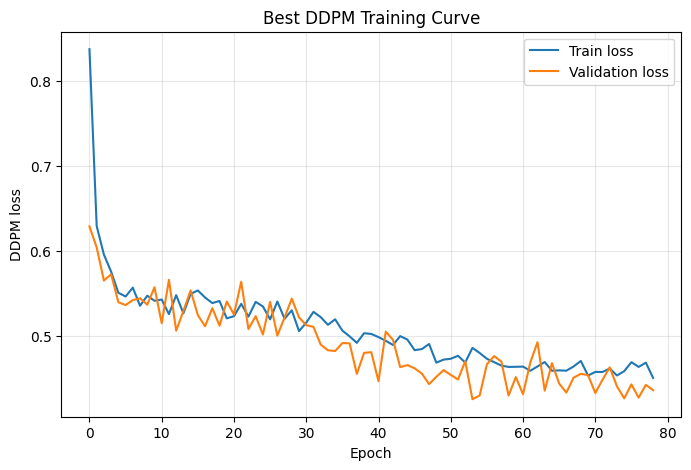

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    best_ddpm_history["train_losses"],
    label="Train loss"
)

plt.plot(
    best_ddpm_history["val_losses"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("DDPM loss")
plt.title("Best DDPM Training Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Learning Rate Schedule During DDPM Training

This cell plots how the learning rate changes during training of the best DDPM model. The learning rate is controlled by the `ReduceLROnPlateau` scheduler, which lowers it when the validation loss stops improving.

This visualization helps confirm that the scheduler was active during training and that the optimizer gradually used smaller updates as the model approached a better solution.


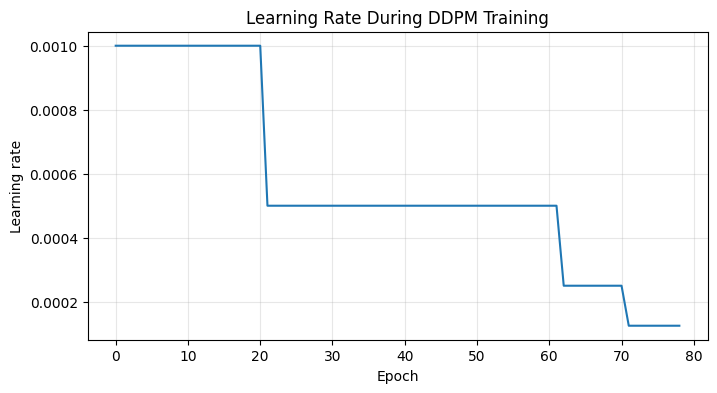

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(best_ddpm_history["learning_rates"])

plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("Learning Rate During DDPM Training")
plt.grid(alpha=0.3)

plt.show()

### Reverse Diffusion Sampling

This cell implements the reverse sampling process of the trained DDPM. Sampling starts from pure Gaussian noise at timestep `t = 100` and gradually denoises the points until reaching `t = 0`.

At each reverse step, the model predicts the noise component in the current sample, and this prediction is used to compute the reverse mean. Selected intermediate states are saved so that we can visualize how the distribution evolves from noise into the learned GMM structure.


In [ ]:
@torch.no_grad()
def sample_reverse_diffusion(model, n_samples=5000, save_steps=[100, 50, 10, 0]):
    model.eval()

    # Start from pure Gaussian noise x_T
    x = torch.randn(n_samples, 2).to(device)

    saved_states = {}

    # Save t = 100, which is pure noise
    if T in save_steps:
        saved_states[T] = x.detach().cpu()

    # Reverse process: t = 100 -> 99 -> ... -> 1 -> 0
    for t in range(T, 0, -1):
        t_tensor = torch.full(
            (n_samples,),
            t,
            device=device,
            dtype=torch.long
        )

        beta_t = betas[t - 1]
        alpha_t = alphas[t - 1]
        alpha_bar_t = alpha_bars[t - 1]

        # Predict the noise epsilon_theta(x_t, t)
        predicted_noise = model(x, t_tensor)

        # Compute the reverse mean
        mean = (1.0 / torch.sqrt(alpha_t)) * (
            x - (beta_t / torch.sqrt(1.0 - alpha_bar_t)) * predicted_noise
        )

        # Add stochastic noise except at the final step
        if t > 1:
            noise = torch.randn_like(x)

            alpha_bar_prev = alpha_bars[t - 2]

            posterior_variance = beta_t * (
                1.0 - alpha_bar_prev
            ) / (
                1.0 - alpha_bar_t
            )

            x = mean + torch.sqrt(posterior_variance) * noise

        else:
            # At t = 1 -> t = 0, no extra noise is added
            x = mean

        # Save selected timesteps
        if (t - 1) in save_steps:
            saved_states[t - 1] = x.detach().cpu()

    return saved_states

### Denormalizing Generated DDPM Samples

This cell defines a helper function that converts normalized samples back to the original 2D coordinate scale. Since the DDPM was trained on normalized GMM data, its generated samples are also produced in the normalized space.

Denormalization is necessary before plotting the generated samples against the original GMM data and mode centers, so that both distributions are shown in the same coordinate system.


In [ ]:
def denormalize(x):
    return x * x_std + x_mean

### Generating Reverse Diffusion States

This cell uses the trained DDPM model to generate samples through the reverse diffusion process. Starting from pure Gaussian noise at `t = 100`, the model progressively denoises the samples and stores selected intermediate timesteps.

The saved states at `t = 100`, `t = 50`, `t = 10`, and `t = 0` are used later to visualize how the distribution evolves from random noise into the learned 2D GMM structure.


In [ ]:
reverse_states = sample_reverse_diffusion(
    model=best_ddpm_model,
    n_samples=5000,
    save_steps=[100, 50, 10, 0]
)

print("Saved timesteps:", reverse_states.keys())

for t, samples in reverse_states.items():
    print(f"t={t}, shape={samples.shape}")

Saved timesteps: dict_keys([100, 50, 10, 0])
t=100, shape=torch.Size([5000, 2])
t=50, shape=torch.Size([5000, 2])
t=10, shape=torch.Size([5000, 2])
t=0, shape=torch.Size([5000, 2])


### Visualizing the Reverse Diffusion Process

This cell plots the DDPM samples at the selected reverse timesteps `t = 100`, `t = 50`, `t = 10`, and `t = 0`. Before plotting, the samples are denormalized so that they return to the original GMM coordinate scale.

These plots show how the reverse diffusion process gradually transforms pure Gaussian noise into structured samples that resemble the target 8-mode GMM distribution. This is the main deliverable for the 2D DDPM task.


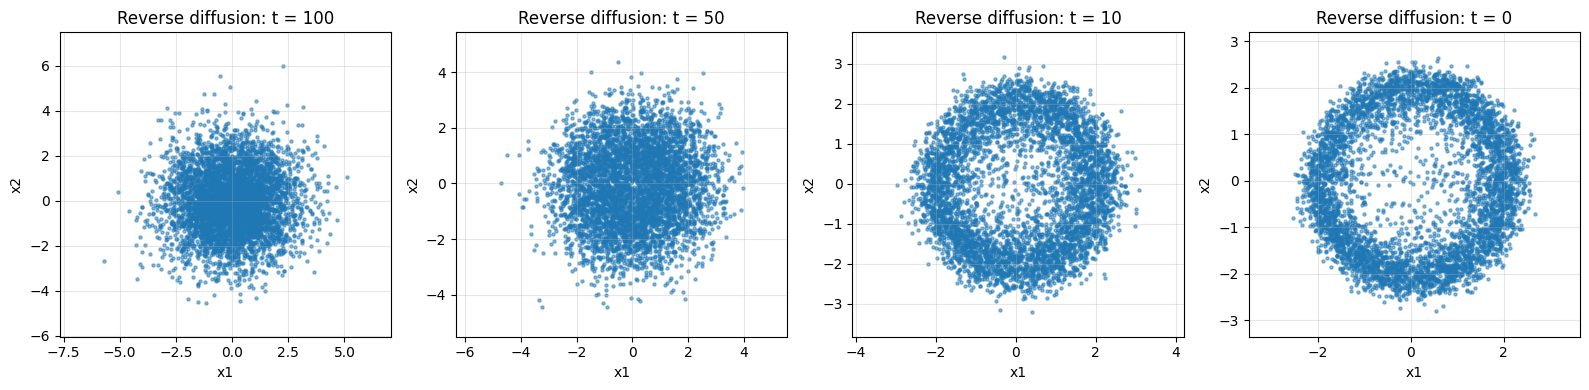

In [ ]:
timesteps_to_plot = [100, 50, 10, 0]

plt.figure(figsize=(16, 4))

for i, t in enumerate(timesteps_to_plot, 1):
    samples_t = reverse_states[t]

    # Back to original GMM scale
    samples_t = denormalize(samples_t).numpy()

    plt.subplot(1, 4, i)

    plt.scatter(
        samples_t[:, 0],
        samples_t[:, 1],
        s=5,
        alpha=0.5
    )

    plt.title(f"Reverse diffusion: t = {t}")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.axis("equal")
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Comparing Real and DDPM-Generated Samples

This cell compares the real GMM data with the final samples generated by the DDPM at `t = 0`. Both sets of points are plotted side by side in the original data space.

This comparison provides a final qualitative evaluation of the DDPM. If the model has learned the target distribution well, the generated samples should reproduce the ring structure and the multiple modes of the real GMM data.


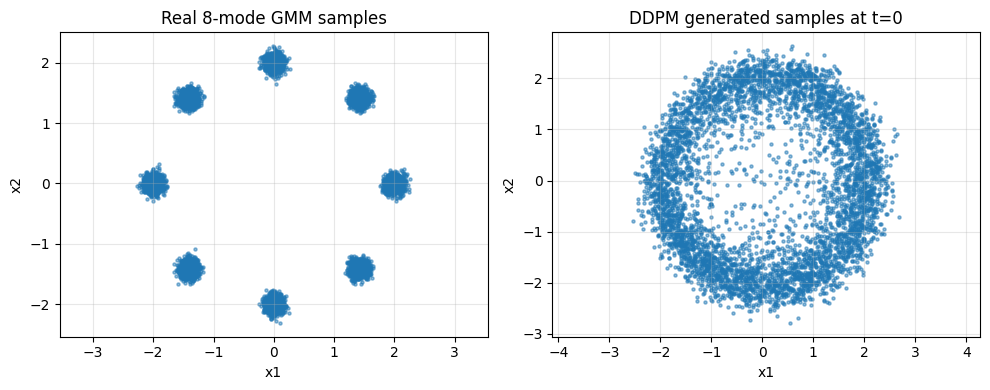

In [ ]:
generated_samples = denormalize(reverse_states[0]).numpy()
real_samples = X_all.numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(
    real_samples[:, 0],
    real_samples[:, 1],
    s=5,
    alpha=0.5
)
plt.title("Real 8-mode GMM samples")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(
    generated_samples[:, 0],
    generated_samples[:, 1],
    s=5,
    alpha=0.5
)
plt.title("DDPM generated samples at t=0")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Task 2: Scaling to Images (MNIST)

### Task 2.1 Convolutional VAE

### Imports, Reproducibility, and Checkpoint Setup for MNIST

This cell imports the libraries needed for the MNIST experiments, including PyTorch, torchvision, plotting tools, and utilities for data loading. We also mount Google Drive so that trained models can be saved and reloaded later.

A fixed random seed is set to make the experiments more reproducible. Unlike Part 1, the MNIST tasks are allowed to use a GPU, so the device is set to CUDA when available. Finally, we create a save directory and define checkpoint paths for storing the best and latest ConvVAE models.


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, random_split

from torchvision import datasets, transforms
from torchvision.utils import make_grid

from google.colab import drive
drive.mount('/content/drive')

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Device: ', device)

SAVE_DIR = "/content/drive/MyDrive/conv_vae_mnist_task_2_1"
os.makedirs(SAVE_DIR, exist_ok=True)

best_checkpoint_path = os.path.join(SAVE_DIR, "best_conv_vae_mnist.pt")
last_checkpoint_path = os.path.join(SAVE_DIR, "last_conv_vae_mnist.pt")

print("Save directory: ", SAVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device:  cuda
Save directory:  /content/drive/MyDrive/conv_vae_mnist_task_2_1


### Loading and Splitting the MNIST Dataset

This cell downloads the MNIST dataset and converts each image into a PyTorch tensor. The original training set is split into 50,000 training images and 10,000 validation images, while the official test set is kept separately.

The `DataLoader` objects are used to feed mini-batches to the model during training, validation, and testing. Using a validation set allows us to monitor the ConvVAE performance during training and save the best checkpoint.


In [ ]:
BATCH_SIZE = 128

transform = transforms.Compose([
    transforms.ToTensor()
])

full_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


train_size = 50000
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("\nTrain size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.3MB/s]


Train size: 50000
Val size: 10000
Test size: 10000


### Inspecting Real MNIST Samples

This cell takes one mini-batch from the training loader and prints the shapes of the image and label tensors. Each MNIST image has shape `1 × 28 × 28`, corresponding to one grayscale channel and a 28 by 28 pixel image.

We also display a 5 × 5 grid of real training images. This gives a visual reference for the data distribution that the ConvVAE will later try to reconstruct and generate.


Images batch shape: torch.Size([128, 1, 28, 28])
Labels batch shape: torch.Size([128])


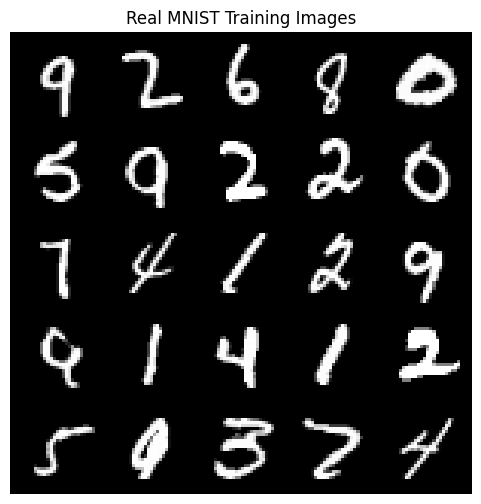

Labels of displayed images:
[9 2 6 8 0 5 9 2 2 0 7 4 1 2 9 9 1 4 1 2 5 9 3 7 4]


In [ ]:
# Get one batch from the training loader
images, labels = next(iter(train_loader))

print("Images batch shape:", images.shape)
print("Labels batch shape:", labels.shape)

# Display first 25 real MNIST images
grid = make_grid(
    images[:25],
    nrow=5,
    padding=2
)

plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1,2,0).squeeze(0), cmap="gray")
plt.axis("off")
plt.title("Real MNIST Training Images")
plt.show()

print("Labels of displayed images:")
print(labels[:25].numpy())

### MNIST Data Sanity Checks and Class Distribution

This cell performs basic checks on the MNIST data before training the ConvVAE. It prints the image and label batch shapes, as well as the minimum, maximum, mean, and standard deviation of the pixel values.

The cell also counts how many examples of each digit appear in the training, validation, and test sets. Plotting the class distribution helps confirm that the split is balanced across the 10 digit classes.


Batch image shape: torch.Size([128, 1, 28, 28])
Batch label shape: torch.Size([128])
Pixel min: 0.0
Pixel max: 1.0
Pixel mean: 0.13304181396961212
Pixel std: 0.3111914396286011


,Digit,Train,Val,Test
0,0,4923,1000,980
1,1,5613,1129,1135
2,2,4958,1000,1032
3,3,5093,1038,1010
4,4,4863,979,982
5,5,4546,875,892
6,6,4933,985,958
7,7,5204,1061,1028
8,8,4882,969,974
9,9,4985,964,1009


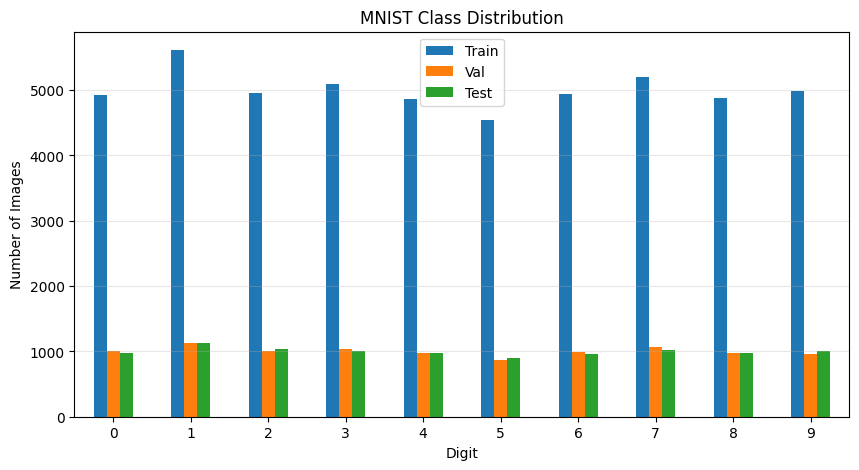

In [ ]:
import pandas as pd

# One batch check
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("Pixel min:", images.min().item())
print("Pixel max:", images.max().item())
print("Pixel mean:", images.mean().item())
print("Pixel std:", images.std().item())

# Labels for train/validation/test set
train_labels = torch.tensor([
    full_train_dataset.targets[i].item()
    for i in train_dataset.indices
])

val_labels = torch.tensor([
    full_train_dataset.targets[i].item()
    for i in val_dataset.indices
])

test_labels = test_dataset.targets


# Count digits 0-9
train_counts = torch.bincount(train_labels, minlength=10)
val_counts = torch.bincount(val_labels, minlength=10)
test_counts = torch.bincount(test_labels, minlength=10)

class_distribution = pd.DataFrame({
    "Digit": list(range(10)),
    "Train": train_counts.numpy(),
    "Val": val_counts.numpy(),
    "Test": test_counts.numpy()
})

display(class_distribution)

# Plot class distribution
class_distribution.set_index("Digit").plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("MNIST Class Distribution")
plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()


### Convolutional VAE Architecture for MNIST

This cell defines the Convolutional Variational Autoencoder used for MNIST image generation. The encoder uses convolutional layers to reduce each `1 × 28 × 28` image into a compact feature representation, which is then mapped to the latent mean `mu` and log-variance `logvar`.

The reparameterization trick is used to sample a latent vector `z` from the learned posterior distribution. The decoder then maps this latent vector back into an image using fully connected and transposed convolutional layers. The final `Sigmoid` activation keeps the reconstructed pixel values in the range `[0, 1]`.


In [ ]:
class ConvVAE(nn.Module):
  def __init__(self, latent_dim=20):
    super().__init__()

    self.latent_dim = latent_dim

    # Encoder downsampling
    # Input: 1x28x28
    # Output: mu and logvar

    self.encoder = nn.Sequential(
        nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=4,
            stride=2,
            padding=1
        ), # 32x14x14
        nn.ReLU(),

        nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=4,
            stride=2,
            padding=1
        ), # 64x7x7
        nn.ReLU(),

        nn.Flatten()

    )

    self.fc_hidden = nn.Linear(64 * 7 * 7, 128)

    self.fc_mu = nn.Linear(128, latent_dim)
    self.fc_logvar = nn.Linear(128, latent_dim)

    # Decoder
    # Input: latent vector z
    # Output: reconstructed image 1x28x28

    self.decoder_input = nn.Sequential(
        nn.Linear(latent_dim, 128),
        nn.ReLU(),

        nn.Linear(128, 64 * 7 * 7),
        nn.ReLU()
    )

    self.decoder = nn.Sequential(
        nn.ConvTranspose2d(
            in_channels=64,
            out_channels=32,
            kernel_size=4,
            stride=2,
            padding=1
        ), # 32x14x14
        nn.ReLU(),

        nn.ConvTranspose2d(
            in_channels=32,
            out_channels=1,
            kernel_size=4,
            stride=2,
            padding=1
        ), # 1x28x28

        nn.Sigmoid()
    )
  def encode(self, x):
    h = self.encoder(x)
    h = F.relu(self.fc_hidden(h))

    mu = self.fc_mu(h)
    logvar = self.fc_logvar(h)

    return mu, logvar

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)

    z = mu + eps * std

    return z

  def decode(self, z):
    h = self.decoder_input(z)
    h = h.view(-1, 64, 7, 7)

    x_recon = self.decoder(h)

    return x_recon

  def forward(self, x):
    mu, logvar = self.encode(x)
    z = self.reparameterize(mu, logvar)
    x_recon = self.decode(z)

    return x_recon, mu, logvar

### ConvVAE Loss Function

This cell defines the loss function used to train the Convolutional VAE. The reconstruction loss is computed with binary cross-entropy, measuring how close the reconstructed MNIST image is to the original input image.

The KL divergence term regularizes the latent distribution by encouraging `q(z|x)` to stay close to the standard normal prior `N(0, I)`. The total VAE loss is the sum of these two terms, corresponding to the negative ELBO objective.


In [ ]:
def vae_loss(x_recon, x, mu, logvar):

  # Reconstruction loss
  # Measures how close the reconstructed image is to input image

  recon_loss = F.binary_cross_entropy(
      x_recon,
      x,
      reduction="sum"
  )

  # KL Divergence
  # Forces q(z|x) to stay close to standard normal N(0,I)

  kl_loss = -0.5 * torch.sum(
      1 + logvar - mu.pow(2) - logvar.exp()
  )

  total_loss = recon_loss + kl_loss

  return total_loss, recon_loss, kl_loss

### Training and Evaluation Functions for the ConvVAE

This cell defines the functions used to train and evaluate the ConvVAE. During training, each mini-batch is passed through the model, the VAE loss is computed, and the optimizer updates the model parameters through backpropagation.

The evaluation function uses the same loss calculation but disables gradient updates. Both functions report the average total loss, reconstruction loss, and KL divergence per image, allowing us to monitor how well the ConvVAE learns during training.


In [ ]:
def train_one_epoch(model, dataloader, optimizer):
  model.train()

  total_loss = 0
  total_recon = 0
  total_kl = 0

  for x, _ in dataloader:
    x = x.to(device)

    optimizer.zero_grad()

    x_recon, mu, logvar = model(x)

    loss, recon_loss, kl_loss = vae_loss(
        x_recon,
        x,
        mu,
        logvar
    )

    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    total_recon += recon_loss.item()
    total_kl += kl_loss.item()

  n = len(dataloader.dataset)

  avg_loss = total_loss / n
  avg_recon = total_recon / n
  avg_kl = total_kl / n

  return avg_loss, avg_recon, avg_kl


def evaluate(model, dataloader):
  model.eval()

  total_loss = 0
  total_recon = 0
  total_kl = 0

  with torch.no_grad():
    for x, _ in dataloader:
      x = x.to(device)

      x_recon, mu, logvar = model(x)

      loss, recon_loss, kl_loss = vae_loss(
          x_recon,
          x,
          mu,
          logvar
      )

      total_loss += loss.item()
      total_recon += recon_loss.item()
      total_kl += kl_loss.item()

    n = len(dataloader.dataset)

    avg_loss = total_loss / n
    avg_recon = total_recon / n
    avg_kl = total_kl / n

    return avg_loss, avg_recon, avg_kl

### Training the ConvVAE on MNIST

This cell trains the Convolutional VAE on the MNIST training set for 20 epochs. For each epoch, we compute the training and validation losses, including the reconstruction loss and KL divergence.

The model is saved whenever it achieves a lower validation loss, ensuring that the best checkpoint is kept. Periodic checkpoints are also saved every 10 epochs so that training progress can be recovered if needed.


In [ ]:
LATENT_DIM = 20
MAX_EPOCHS = 20
LR = 1e-3
CHECKPOINT_EVERY = 10

model = ConvVAE(latent_dim=LATENT_DIM).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)

best_val_loss = float("inf")

history = {
    "train_loss": [],
    "val_loss": [],
    "train_recon": [],
    "val_recon": [],
    "train_kl": [],
    "val_kl": []
}

for epoch in range(1, MAX_EPOCHS + 1):

    train_loss, train_recon, train_kl = train_one_epoch(
        model,
        train_loader,
        optimizer
    )

    val_loss, val_recon, val_kl = evaluate(
        model,
        val_loader
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_recon"].append(train_recon)
    history["val_recon"].append(val_recon)
    history["train_kl"].append(train_kl)
    history["val_kl"].append(val_kl)

    print(
        f"Epoch [{epoch:02d}/{MAX_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Recon: {train_recon:.4f} | "
        f"Train KL: {train_kl:.4f} || "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Recon: {val_recon:.4f} | "
        f"Val KL: {val_kl:.4f}"
    )

    # Save best model according to validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_loss": best_val_loss,
            "latent_dim": LATENT_DIM,
            "history": history
        }, best_checkpoint_path)

        print(f"Saved best model at epoch {epoch}")

    # Save periodic checkpoint every 10 epochs
    if epoch % CHECKPOINT_EVERY == 0:
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_loss": best_val_loss,
            "latent_dim": LATENT_DIM,
            "history": history
        }, last_checkpoint_path)

        print(f"Saved periodic checkpoint at epoch {epoch}")

print("Training finished.")
print("Best validation loss:", best_val_loss)

Epoch [01/20] Train Loss: 195.5810 | Train Recon: 190.2749 | Train KL: 5.3061 || Val Loss: 149.0018 | Val Recon: 135.4957 | Val KL: 13.5061
Saved best model at epoch 1
Epoch [02/20] Train Loss: 133.1735 | Train Recon: 117.0457 | Train KL: 16.1278 || Val Loss: 123.9400 | Val Recon: 106.5764 | Val KL: 17.3635
Saved best model at epoch 2
Epoch [03/20] Train Loss: 118.0442 | Train Recon: 100.1627 | Train KL: 17.8814 || Val Loss: 114.1843 | Val Recon: 95.7485 | Val KL: 18.4357
Saved best model at epoch 3
Epoch [04/20] Train Loss: 111.2860 | Train Recon: 92.5635 | Train KL: 18.7225 || Val Loss: 109.5266 | Val Recon: 90.1715 | Val KL: 19.3551
Saved best model at epoch 4
Epoch [05/20] Train Loss: 108.2186 | Train Recon: 89.1352 | Train KL: 19.0834 || Val Loss: 107.6875 | Val Recon: 88.4541 | Val KL: 19.2334
Saved best model at epoch 5
Epoch [06/20] Train Loss: 106.5396 | Train Recon: 87.1665 | Train KL: 19.3731 || Val Loss: 106.3456 | Val Recon: 87.0927 | Val KL: 19.2529
Saved best model at ep

### ConvVAE Training Curve

This cell plots the training and validation loss curves of the Convolutional VAE across epochs. The loss is reported per image and includes both the reconstruction loss and the KL divergence term.

This plot helps us check whether the model learns steadily and whether the validation loss follows the training loss. A decreasing and stable validation curve indicates that the ConvVAE is improving without clear signs of overfitting.


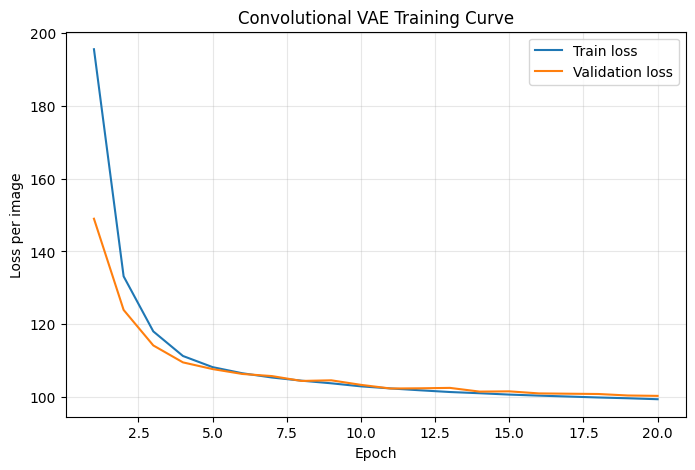

In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["val_loss"], label="Validation loss")


plt.xlabel("Epoch")
plt.ylabel("Loss per image")
plt.title("Convolutional VAE Training Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Reconstruction and KL Loss Curves

This cell plots the two main components of the ConvVAE objective separately. The reconstruction loss shows how well the decoder learns to reproduce the input MNIST images, while the KL divergence shows how strongly the latent space is regularized toward the standard normal prior.

Inspecting these two curves separately helps us understand the trade-off learned by the VAE. Ideally, the reconstruction loss should decrease while the KL term remains stable enough to preserve a useful latent representation.


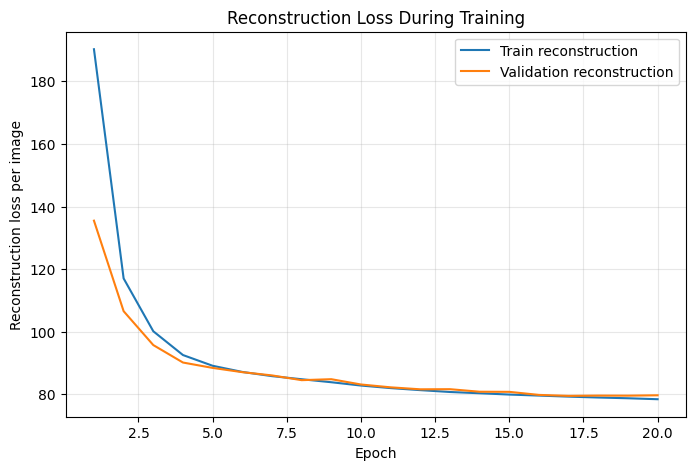

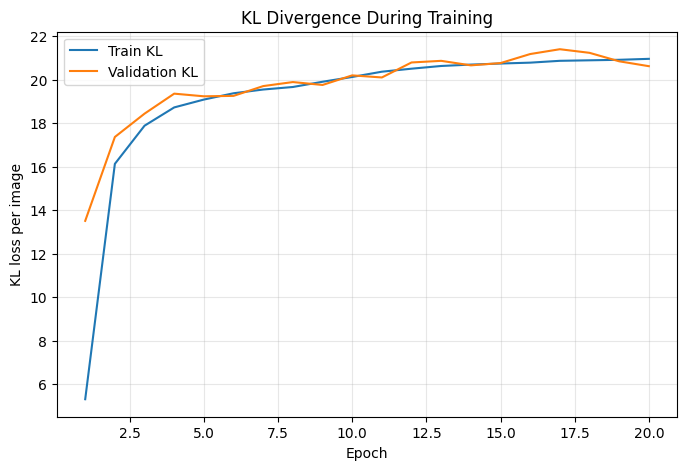

In [ ]:
# =====================================================
# Plot reconstruction and KL losses
# =====================================================

plt.figure(figsize=(8, 5))

plt.plot(epochs, history["train_recon"], label="Train reconstruction")
plt.plot(epochs, history["val_recon"], label="Validation reconstruction")

plt.xlabel("Epoch")
plt.ylabel("Reconstruction loss per image")
plt.title("Reconstruction Loss During Training")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


plt.figure(figsize=(8, 5))

plt.plot(epochs, history["train_kl"], label="Train KL")
plt.plot(epochs, history["val_kl"], label="Validation KL")

plt.xlabel("Epoch")
plt.ylabel("KL loss per image")
plt.title("KL Divergence During Training")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Loading the Best ConvVAE Checkpoint

This cell loads the best saved ConvVAE checkpoint from Google Drive. The latent dimension stored in the checkpoint is used to reconstruct the same model architecture before loading the trained weights.

After loading the weights, the model is switched to evaluation mode. This ensures that the following reconstruction and generation experiments use the best validation checkpoint rather than the final training state.


In [ ]:
checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device,
    weights_only=True
)

loaded_latent_dim = checkpoint["latent_dim"]

best_model = ConvVAE(
    latent_dim=loaded_latent_dim
).to(device)

best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

print("Loaded best model from epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["best_val_loss"])
print("Latent dimension:", loaded_latent_dim)

Loaded best model from epoch: 20
Best validation loss: 100.32131218261719
Latent dimension: 20


### Generating New MNIST Digits from the ConvVAE

This cell samples 25 latent vectors from the standard normal prior `N(0, I)` and decodes them into MNIST-like images using the trained ConvVAE decoder. The generated images are then displayed in a 5 × 5 grid.

This is one of the main deliverables of Task 2.1, since it shows whether the ConvVAE has learned a meaningful latent representation that can produce realistic handwritten digits from random latent samples.


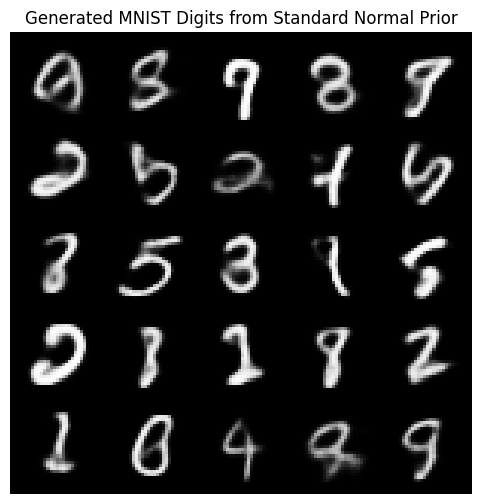

In [ ]:
best_model.eval()

with torch.no_grad():
  z = torch.randn(25, loaded_latent_dim).to(device)

  # Decode latent vectors into generated MNIST images
  generated_digits = best_model.decode(z).cpu()


# Create 5x5 grid
grid = make_grid(
    generated_digits,
    nrow=5,
    padding=2
)

plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1,2,0).squeeze(), cmap="gray")
plt.axis("off")
plt.title("Generated MNIST Digits from Standard Normal Prior")
plt.show()

### Selecting a Digit for Latent Interpolation

This cell defines a helper function that searches through a dataset and returns the first image matching a requested digit label. The selected image is returned with an added batch dimension, so it can be passed directly into the ConvVAE encoder.

This function is useful for latent-space interpolation, where we choose two real MNIST digits, encode them into latent vectors, and then generate intermediate images between them.


In [ ]:
def get_digit_sample(dataset, target_digit):
  for x, y in dataset:
    if y == target_digit:
      return x.unsqueeze(0), y

  raise ValueError(f"Digit {target_digit} not found.")

### Latent Space Interpolation Between Two Digits

This cell performs a linear interpolation in the latent space between two real MNIST digits, here digit `2` and digit `7`. First, both images are encoded by the ConvVAE, and we use their latent mean vectors as the endpoints of the interpolation.

Intermediate latent vectors are then generated between these two points and decoded back into images. This helps us visualize whether the latent space learned by the VAE is smooth and meaningful, since a good latent representation should produce a gradual transition from one digit to the other.


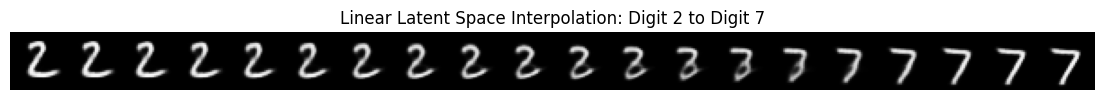

In [ ]:
start_digit = 2
end_digit = 7

x1, y1 = get_digit_sample(test_dataset, start_digit)
x2, y2 = get_digit_sample(test_dataset, end_digit)

x1 = x1.to(device)
x2 = x2.to(device)

best_model.eval()

with torch.no_grad():
    mu1, logvar1 = best_model.encode(x1)
    mu2, logvar2 = best_model.encode(x2)

    # Use the latent means for interpolation
    z1 = mu1
    z2 = mu2

    alphas = torch.linspace(0, 1, steps=20).to(device)

    z_interpolated = []

    for alpha in alphas:
        z = (1 - alpha) * z1 + alpha * z2
        z_interpolated.append(z)

    z_interpolated = torch.cat(z_interpolated, dim=0)

    interpolated_digits = best_model.decode(z_interpolated).cpu()

grid = make_grid(
    interpolated_digits,
    nrow=20,
    padding=2
)

plt.figure(figsize=(14, 2))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title(f"Linear Latent Space Interpolation: Digit {start_digit} to Digit {end_digit}")
plt.show()

### Task 2.2: Deep Convolutional GAN (DCGAN)

### Preparing MNIST Data for DCGAN Training

This cell prepares a separate MNIST `DataLoader` for the DCGAN experiment. Unlike the ConvVAE, the images are normalized from `[0, 1]` to `[-1, 1]`, which matches the `Tanh` output activation commonly used in GAN generators.

The printed batch shape and pixel range confirm that the images have the expected format before training the generator and discriminator.


In [ ]:
# DCGAN setup: MNIST DataLoader with normalization to [-1, 1]

GAN_BATCH_SIZE = 128

gan_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5,),
        std=(0.5,)
    )
])

gan_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=gan_transform
)

gan_train_loader = DataLoader(
    gan_train_dataset,
    batch_size=GAN_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("GAN train dataset:", len(gan_train_dataset))

images, labels = next(iter(gan_train_loader))

print("Batch image shape:", images.shape)
print("Pixel min:", images.min().item())
print("Pixel max:", images.max().item())

GAN train dataset: 60000
Batch image shape: torch.Size([128, 1, 28, 28])
Pixel min: -1.0
Pixel max: 1.0


### DCGAN Generator and Discriminator Architectures

This cell defines the two convolutional networks used in the DCGAN. The generator takes a random noise vector of shape `100 × 1 × 1` and progressively upsamples it using transposed convolutional layers until it produces a `1 × 28 × 28` MNIST-like image.

The discriminator performs the opposite operation. It receives either a real or generated MNIST image and uses convolutional layers to output the probability that the image is real. These two networks are trained adversarially, with the generator trying to fool the discriminator and the discriminator trying to distinguish real images from fake ones.


In [ ]:
# =====================================================
# DCGAN Generator
# Input: noise z of shape [batch_size, 100, 1, 1]
# Output: fake image of shape [batch_size, 1, 28, 28]
# =====================================================

class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()

        self.noise_dim = noise_dim

        self.net = nn.Sequential(
            # [B, 100, 1, 1] -> [B, 256, 7, 7]
            nn.ConvTranspose2d(
                in_channels=noise_dim,
                out_channels=256,
                kernel_size=7,
                stride=1,
                padding=0,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # [B, 256, 7, 7] -> [B, 128, 14, 14]
            nn.ConvTranspose2d(
                in_channels=256,
                out_channels=128,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # [B, 128, 14, 14] -> [B, 64, 28, 28]
            nn.ConvTranspose2d(
                in_channels=128,
                out_channels=64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # [B, 64, 28, 28] -> [B, 1, 28, 28]
            nn.ConvTranspose2d(
                in_channels=64,
                out_channels=1,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


# =====================================================
# DCGAN Discriminator
# Input: image of shape [batch_size, 1, 28, 28]
# Output: probability of being real
# =====================================================

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            # [B, 1, 28, 28] -> [B, 64, 14, 14]
            nn.Conv2d(
                in_channels=1,
                out_channels=64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # [B, 64, 14, 14] -> [B, 128, 7, 7]
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # [B, 128, 7, 7] -> [B, 256, 4, 4]
            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # [B, 256, 4, 4] -> [B, 1, 1, 1]
            nn.Conv2d(
                in_channels=256,
                out_channels=1,
                kernel_size=4,
                stride=1,
                padding=0,
                bias=False
            ),
            nn.Sigmoid()
        )

    def forward(self, x):
        out = self.net(x)
        return out.view(-1, 1)

### Sanity Check for the DCGAN Networks

This cell tests whether the DCGAN generator and discriminator are connected correctly. Random noise vectors are passed through the generator to produce fake MNIST images, and both fake and real images are then passed through the discriminator.

The printed shapes confirm that the generator outputs images of size `1 × 28 × 28` and that the discriminator produces one real/fake probability per image. This check verifies that the two networks are compatible before starting adversarial training.


In [ ]:
NOISE_DIM = 100

G = Generator(noise_dim=NOISE_DIM).to(device)
D = Discriminator().to(device)

# Fake noise
z = torch.randn(128, NOISE_DIM, 1, 1).to(device)

# Generate fake images
fake_images = G(z)

# Discriminator outputs
d_out_fake = D(fake_images)

# Real batch
real_images, _ = next(iter(gan_train_loader))
real_images = real_images.to(device)
d_out_real = D(real_images)

print("Noise shape:", z.shape)
print("Fake images shape:", fake_images.shape)
print("Fake image min:", fake_images.min().item())
print("Fake image max:", fake_images.max().item())
print("Discriminator output on fake:", d_out_fake.shape)
print("Real images shape:", real_images.shape)
print("Discriminator output on real:", d_out_real.shape)

Noise shape: torch.Size([128, 100, 1, 1])
Fake images shape: torch.Size([128, 1, 28, 28])
Fake image min: -1.0
Fake image max: 1.0
Discriminator output on fake: torch.Size([128, 1])
Real images shape: torch.Size([128, 1, 28, 28])
Discriminator output on real: torch.Size([128, 1])


### DCGAN Training Setup

This cell initializes the full DCGAN training setup. We define the noise dimension, learning rate, Adam optimizer parameters, number of training epochs, and checkpoint paths for saving the trained generator and discriminator.

The generator and discriminator are initialized using the standard DCGAN weight initialization strategy, which helps stabilize adversarial training. We also define the binary cross-entropy loss, optimizers for both networks, fixed noise for monitoring generated samples across epochs, and lists for storing generator and discriminator losses.


In [ ]:
# =====================================================
# DCGAN loss, optimizers, and initialization
# =====================================================

NOISE_DIM = 100
GAN_LR = 2e-4
BETA1 = 0.5
GAN_EPOCHS = 25
GAN_CHECKPOINT_EVERY = 5

gan_save_dir = "/content/drive/MyDrive/dcgan_mnist_task_2_2"
os.makedirs(gan_save_dir, exist_ok=True)

best_gan_checkpoint_path = os.path.join(gan_save_dir, "final_dcgan_mnist.pt")
last_gan_checkpoint_path = os.path.join(gan_save_dir, "last_dcgan_mnist.pt")


def weights_init(m):
    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(
            m.weight.data,
            mean=0.0,
            std=0.02
        )

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(
            m.weight.data,
            mean=1.0,
            std=0.02
        )
        nn.init.constant_(
            m.bias.data,
            0
        )


G = Generator(noise_dim=NOISE_DIM).to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(
    G.parameters(),
    lr=GAN_LR,
    betas=(BETA1, 0.999)
)

optimizer_D = torch.optim.Adam(
    D.parameters(),
    lr=GAN_LR,
    betas=(BETA1, 0.999)
)

# Fixed noise for monitoring generation progress across epochs
fixed_noise = torch.randn(25, NOISE_DIM, 1, 1).to(device)

G_losses = []
D_losses = []

print("DCGAN setup complete.")
print("Noise dimension:", NOISE_DIM)
print("Learning rate:", GAN_LR)
print("Adam beta1:", BETA1)
print("Max epochs:", GAN_EPOCHS)
print("Checkpoint every:", GAN_CHECKPOINT_EVERY, "epochs")

DCGAN setup complete.
Noise dimension: 100
Learning rate: 0.0002
Adam beta1: 0.5
Max epochs: 25
Checkpoint every: 5 epochs


### Training the DCGAN on MNIST

This cell trains the DCGAN using adversarial learning. For each batch, the discriminator is first trained to distinguish real MNIST images from fake images generated by the generator. Then, the generator is trained to produce fake images that the discriminator classifies as real.

The discriminator and generator losses are stored after each epoch so that training behavior can be visualized later. Checkpoints are saved during training, and the final generator and discriminator weights are saved at the end for later image generation.


In [ ]:
# DCGAN training loop

G_losses = []
D_losses = []

for epoch in range(1, GAN_EPOCHS + 1):

    G.train()
    D.train()

    total_G_loss = 0.0
    total_D_loss = 0.0

    for real_images, _ in gan_train_loader:

        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # Labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)


        # Train Discriminator
        # Maximize log(D(x)) + log(1 - D(G(z)))


        optimizer_D.zero_grad()

        # Real images
        real_outputs = D(real_images)
        d_loss_real = criterion(real_outputs, real_labels)

        # Fake images
        z = torch.randn(batch_size, NOISE_DIM, 1, 1).to(device)
        fake_images = G(z)

        fake_outputs = D(fake_images.detach())
        d_loss_fake = criterion(fake_outputs, fake_labels)

        # Total discriminator loss
        d_loss = d_loss_real + d_loss_fake

        d_loss.backward()
        optimizer_D.step()


        # Train Generator
        # Maximize log(D(G(z)))
        # Equivalently: make fake images classified as real


        optimizer_G.zero_grad()

        fake_outputs = D(fake_images)
        g_loss = criterion(fake_outputs, real_labels)

        g_loss.backward()
        optimizer_G.step()

        total_D_loss += d_loss.item()
        total_G_loss += g_loss.item()

    avg_D_loss = total_D_loss / len(gan_train_loader)
    avg_G_loss = total_G_loss / len(gan_train_loader)

    D_losses.append(avg_D_loss)
    G_losses.append(avg_G_loss)

    print(
        f"Epoch [{epoch:02d}/{GAN_EPOCHS}] "
        f"D Loss: {avg_D_loss:.4f} | "
        f"G Loss: {avg_G_loss:.4f}"
    )

    # Save checkpoint every 5 epochs
    if epoch % GAN_CHECKPOINT_EVERY == 0:
        torch.save({
            "epoch": epoch,
            "G_state_dict": G.state_dict(),
            "D_state_dict": D.state_dict(),
            "optimizer_G_state_dict": optimizer_G.state_dict(),
            "optimizer_D_state_dict": optimizer_D.state_dict(),
            "noise_dim": NOISE_DIM,
            "G_losses": G_losses,
            "D_losses": D_losses
        }, last_gan_checkpoint_path)

        print(f"Saved DCGAN checkpoint at epoch {epoch}")

# Save final model
torch.save({
    "epoch": GAN_EPOCHS,
    "G_state_dict": G.state_dict(),
    "D_state_dict": D.state_dict(),
    "optimizer_G_state_dict": optimizer_G.state_dict(),
    "optimizer_D_state_dict": optimizer_D.state_dict(),
    "noise_dim": NOISE_DIM,
    "G_losses": G_losses,
    "D_losses": D_losses
}, best_gan_checkpoint_path)

print("DCGAN training finished.")
print("Final D loss:", D_losses[-1])
print("Final G loss:", G_losses[-1])

Epoch [01/25] D Loss: 0.5239 | G Loss: 2.3778
Epoch [02/25] D Loss: 0.6647 | G Loss: 1.9413
Epoch [03/25] D Loss: 0.6422 | G Loss: 1.9630
Epoch [04/25] D Loss: 0.6327 | G Loss: 1.9931
Epoch [05/25] D Loss: 0.6410 | G Loss: 1.9850
Saved DCGAN checkpoint at epoch 5
Epoch [06/25] D Loss: 0.6353 | G Loss: 2.0095
Epoch [07/25] D Loss: 0.6145 | G Loss: 2.0815
Epoch [08/25] D Loss: 0.6481 | G Loss: 2.0550
Epoch [09/25] D Loss: 0.6404 | G Loss: 2.0679
Epoch [10/25] D Loss: 0.6133 | G Loss: 2.1248
Saved DCGAN checkpoint at epoch 10
Epoch [11/25] D Loss: 0.5732 | G Loss: 2.2186
Epoch [12/25] D Loss: 0.5681 | G Loss: 2.2852
Epoch [13/25] D Loss: 0.5695 | G Loss: 2.2589
Epoch [14/25] D Loss: 0.5949 | G Loss: 2.2583
Epoch [15/25] D Loss: 0.5200 | G Loss: 2.3781
Saved DCGAN checkpoint at epoch 15
Epoch [16/25] D Loss: 0.5772 | G Loss: 2.3293
Epoch [17/25] D Loss: 0.5469 | G Loss: 2.3645
Epoch [18/25] D Loss: 0.5210 | G Loss: 2.4072
Epoch [19/25] D Loss: 0.4929 | G Loss: 2.5077
Epoch [20/25] D Loss: 

### DCGAN Training Loss Curves

This cell plots the generator and discriminator losses across training epochs. The discriminator loss measures how well the discriminator separates real MNIST images from generated ones, while the generator loss measures how well the generator fools the discriminator.

These curves help us monitor the adversarial training dynamics. Unlike standard supervised learning, GAN losses do not always decrease smoothly, because the generator and discriminator are trained against each other.


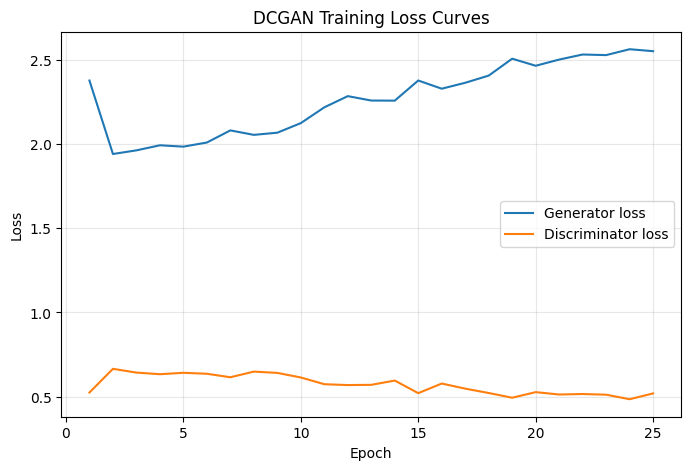

In [ ]:
epochs = range(1, len(G_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, G_losses, label="Generator loss")
plt.plot(epochs, D_losses, label="Discriminator loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Training Loss Curves")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Generating MNIST Digits with the Trained DCGAN

This cell samples random noise vectors and passes them through the trained generator to produce new MNIST-like digits. Since the generator outputs images in the range `[-1, 1]`, we convert them back to `[0, 1]` before visualization.

The generated images are displayed in a 5 × 5 grid. This is the main visual deliverable for the DCGAN task and allows us to assess whether the generator has learned to produce realistic handwritten digits.


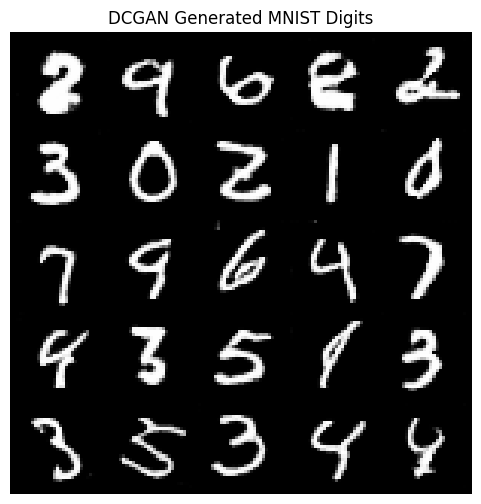

In [ ]:
G.eval()

with torch.no_grad():
    z = torch.randn(25, NOISE_DIM, 1, 1).to(device)
    fake_digits = G(z).cpu()

# Convert from [-1, 1] back to [0, 1] for visualization
fake_digits = (fake_digits + 1) / 2

grid = make_grid(
    fake_digits,
    nrow=5,
    padding=2
)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title("DCGAN Generated MNIST Digits")
plt.show()

### Task 2.3: Micro U-NET Diffusion

### Preparing MNIST Data for the Micro-U-Net DDPM

This cell sets up the MNIST dataset for the image-based DDPM experiment. The images are normalized from `[0, 1]` to `[-1, 1]`, which is a common preprocessing step for diffusion models and matches the scale used during reverse sampling.

We also define the number of diffusion steps `T = 250` and create a training `DataLoader` for mini-batch training. The printed image shape and pixel range confirm that the data has the expected format before training the Micro-U-Net noise predictor.


In [ ]:
# Task 2.3: Micro-U-Net DDPM setup
# MNIST normalized to [-1, 1]

DDPM_BATCH_SIZE = 128
T = 250

ddpm_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5,),
        std=(0.5,)
    )
])

ddpm_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=ddpm_transform
)

ddpm_train_loader = DataLoader(
    ddpm_train_dataset,
    batch_size=DDPM_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("DDPM train dataset:", len(ddpm_train_dataset))

images, labels = next(iter(ddpm_train_loader))

print("Batch image shape:", images.shape)
print("Pixel min:", images.min().item())
print("Pixel max:", images.max().item())

DDPM train dataset: 60000
Batch image shape: torch.Size([128, 1, 28, 28])
Pixel min: -1.0
Pixel max: 1.0


### DDPM Forward Noise Schedule for MNIST

This cell defines the forward diffusion noise schedule for the MNIST DDPM. The noise variance starts from a very small value and increases linearly over `T = 250` diffusion steps.

The precomputed values `alphas`, `alpha_bars`, and their square roots are used during both the forward noising process and the reverse denoising process. The printed `alpha_bar` values show how much of the original image signal remains at the beginning and at the final diffusion step.


In [ ]:
# DDPM forward process schedule

# quantities of noise added in each step
beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(
    beta_start,
    beta_end,
    T,
    device=device
)

alphas = 1.0 - betas

alpha_bars = torch.cumprod(
    alphas,
    dim=0
)

sqrt_alpha_bars = torch.sqrt(alpha_bars)
sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)

print("T:", T)
print("beta_start:", betas[0].item())
print("beta_end:", betas[-1].item())
print("alpha_bar at t=0:", alpha_bars[0].item())
print("alpha_bar at t=T-1:", alpha_bars[-1].item())

T: 250
beta_start: 9.999999747378752e-05
beta_end: 0.019999999552965164
alpha_bar at t=0: 0.9998999834060669
alpha_bar at t=T-1: 0.07970252633094788


### Forward Diffusion Function for MNIST Images

This cell implements the forward diffusion process `q(x_t | x_0)` for MNIST images. The helper function `extract` selects the correct precomputed noise-schedule values for each image in the batch and reshapes them so they can be broadcast across image dimensions.

The `q_sample` function then adds Gaussian noise to clean images according to their selected timesteps. This produces noisy images `x_t`, which are used as inputs during DDPM training while the model learns to predict the added noise.


In [ ]:
# Helper function: forward diffusion q(x_t | x_0)

def extract(values, timesteps, x_shape):
    """
    Extract values for specific timesteps and reshape for broadcasting.
    values: tensor of shape [T]
    timesteps: tensor of shape [batch_size]
    x_shape: shape of image batch
    """

    # how many images are processed simultaneously
    batch_size = timesteps.shape[0]

    out = values.gather(
        dim=0,
        index=timesteps
    )

    return out.view(batch_size, 1, 1, 1)


def q_sample(x_start, timesteps, noise=None):
    """
    Add noise to clean image x_start at given timesteps.
    """
    if noise is None:
        noise = torch.randn_like(x_start)

    sqrt_alpha_bar_t = extract(
        sqrt_alpha_bars,
        timesteps,
        x_start.shape
    )

    sqrt_one_minus_alpha_bar_t = extract(
        sqrt_one_minus_alpha_bars,
        timesteps,
        x_start.shape
    )

    x_t = sqrt_alpha_bar_t * x_start + sqrt_one_minus_alpha_bar_t * noise

    return x_t, noise

### Visual Check of the Forward Diffusion Process

This cell provides a visual sanity check of the forward diffusion process on a real MNIST image. We progressively add noise to the same image at several timesteps and display the results side by side.

This helps verify that the forward process behaves as expected: at small timesteps the digit remains mostly visible, while at larger timesteps it becomes increasingly corrupted by noise. This confirms that the DDPM noising schedule is working properly before training the reverse denoising model.


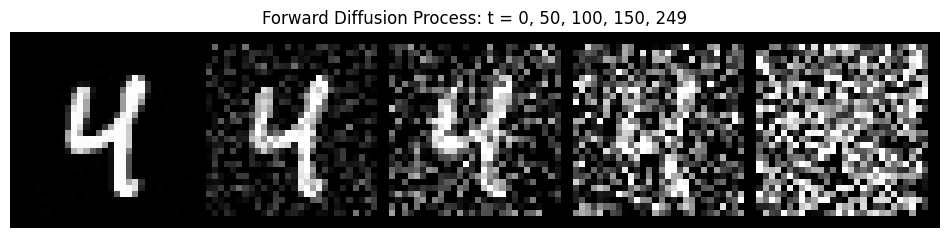

In [ ]:
# Visual check: forward diffusion process

images, _ = next(iter(ddpm_train_loader))
x0 = images[:1].to(device)

timesteps_to_show = [0, 50, 100, 150, 249]

noisy_images = []

# Use the same noise across timesteps for a cleaner visual progression
fixed_noise = torch.randn_like(x0)

with torch.no_grad():
    for t in timesteps_to_show:
        timestep = torch.tensor([t], device=device).long()
        x_t, _ = q_sample(x0, timestep)
        noisy_images.append(x_t.cpu())

noisy_images = torch.cat(noisy_images, dim=0)

# Convert from [-1, 1] to [0, 1] for visualization
noisy_images_vis = (noisy_images + 1) / 2
noisy_images_vis = torch.clamp(noisy_images_vis, 0, 1)

grid = make_grid(
    noisy_images_vis,
    nrow=5,
    padding=2
)

plt.figure(figsize=(12, 3))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title("Forward Diffusion Process: t = 0, 50, 100, 150, 249")
plt.show()

### Micro-U-Net Noise Predictor Architecture

This cell defines the neural network used as the noise predictor for the MNIST DDPM. First, a sinusoidal timestep embedding is used so that the model knows the current diffusion timestep for each image.

The `ResBlock` modules add timestep conditioning inside convolutional residual blocks. The final `MicroUNet` follows an encoder-decoder structure with skip connections, allowing the model to capture both low-level image details and higher-level spatial structure. Its output has the same shape as the input image and represents the predicted Gaussian noise added during the forward diffusion process.


In [ ]:
# Sinusoidal timestep embedding

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, time_dim):
        super().__init__()
        self.time_dim = time_dim

    def forward(self, t):
        """
        t: [batch_size]
        returns: [batch_size, time_dim]
        """
        half_dim = self.time_dim // 2

        emb_factor = torch.log(torch.tensor(10000.0, device=t.device)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb_factor)

        emb = t[:, None].float() * emb[None, :]

        emb = torch.cat(
            [torch.sin(emb), torch.cos(emb)],
            dim=1
        )

        return emb


# Basic residual block with timestep conditioning

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm1 = nn.GroupNorm(
            num_groups=8,
            num_channels=out_channels
        )

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm2 = nn.GroupNorm(
            num_groups=8,
            num_channels=out_channels
        )

        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, out_channels)
        )

        if in_channels != out_channels:
            self.residual_conv = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1
            )
        else:
            self.residual_conv = nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h)

        time_emb = self.time_mlp(t_emb)
        h = h + time_emb[:, :, None, None]

        h = self.conv2(h)
        h = self.norm2(h)
        h = F.silu(h)

        return h + self.residual_conv(x)


# Micro U-Net for MNIST DDPM
# Channels: 32, 64, 128

class MicroUNet(nn.Module):
    def __init__(self, image_channels=1, base_channels=32, time_dim=128):
        super().__init__()

        self.time_embedding = SinusoidalTimeEmbedding(time_dim)

        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        # Initial projection: 1 x 28 x 28 -> 32 x 28 x 28
        self.init_conv = nn.Conv2d(
            image_channels,
            base_channels,
            kernel_size=3,
            padding=1
        )

        # Downsampling path
        self.down1 = ResBlock(
            in_channels=base_channels,
            out_channels=base_channels,
            time_dim=time_dim
        )

        self.downsample1 = nn.Conv2d(
            base_channels,
            base_channels * 2,
            kernel_size=4,
            stride=2,
            padding=1
        )  # 32 x 28 x 28 -> 64 x 14 x 14

        self.down2 = ResBlock(
            in_channels=base_channels * 2,
            out_channels=base_channels * 2,
            time_dim=time_dim
        )

        self.downsample2 = nn.Conv2d(
            base_channels * 2,
            base_channels * 4,
            kernel_size=4,
            stride=2,
            padding=1
        )  # 64 x 14 x 14 -> 128 x 7 x 7

        # Bottleneck
        self.bottleneck = ResBlock(
            in_channels=base_channels * 4,
            out_channels=base_channels * 4,
            time_dim=time_dim
        )

        # Upsampling path
        self.upsample1 = nn.ConvTranspose2d(
            base_channels * 4,
            base_channels * 2,
            kernel_size=4,
            stride=2,
            padding=1
        )  # 128 x 7 x 7 -> 64 x 14 x 14

        self.up1 = ResBlock(
            in_channels=base_channels * 4,   # concat: 64 + 64
            out_channels=base_channels * 2,
            time_dim=time_dim
        )

        self.upsample2 = nn.ConvTranspose2d(
            base_channels * 2,
            base_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )  # 64 x 14 x 14 -> 32 x 28 x 28

        self.up2 = ResBlock(
            in_channels=base_channels * 2,   # concat: 32 + 32
            out_channels=base_channels,
            time_dim=time_dim
        )

        # Final prediction: predicted noise
        self.final_conv = nn.Conv2d(
            base_channels,
            image_channels,
            kernel_size=1
        )

    def forward(self, x, t):
        # Timestep embedding
        t_emb = self.time_embedding(t)
        t_emb = self.time_mlp(t_emb)

        # Initial conv
        x = self.init_conv(x)

        # Down path
        skip1 = self.down1(x, t_emb)              # [B, 32, 28, 28]
        x = self.downsample1(skip1)               # [B, 64, 14, 14]

        skip2 = self.down2(x, t_emb)              # [B, 64, 14, 14]
        x = self.downsample2(skip2)               # [B, 128, 7, 7]

        # Bottleneck
        x = self.bottleneck(x, t_emb)             # [B, 128, 7, 7]

        # Up path
        x = self.upsample1(x)                     # [B, 64, 14, 14]
        x = torch.cat([x, skip2], dim=1)          # [B, 128, 14, 14]
        x = self.up1(x, t_emb)                    # [B, 64, 14, 14]

        x = self.upsample2(x)                     # [B, 32, 28, 28]
        x = torch.cat([x, skip1], dim=1)          # [B, 64, 28, 28]
        x = self.up2(x, t_emb)                    # [B, 32, 28, 28]

        noise_pred = self.final_conv(x)           # [B, 1, 28, 28]

        return noise_pred

### Sanity Check for the Micro-U-Net

This cell tests whether the Micro-U-Net noise predictor produces outputs with the correct shape. A batch of MNIST images and randomly sampled diffusion timesteps are passed through the model.

The predicted noise should have the same shape as the input images, namely `[batch_size, 1, 28, 28]`. This confirms that the model architecture is compatible with the DDPM training objective before starting full training.


In [ ]:
ddpm_model = MicroUNet(
    image_channels=1,
    base_channels=32,
    time_dim=128
).to(device)

images, _ = next(iter(ddpm_train_loader))
images = images.to(device)

batch_size = images.size(0)

t = torch.randint(
    low=0,
    high=T,
    size=(batch_size,),
    device=device
).long()

with torch.no_grad():
    noise_pred = ddpm_model(images, t)

print("Input images shape:", images.shape)
print("Timesteps shape:", t.shape)
print("Predicted noise shape:", noise_pred.shape)

Input images shape: torch.Size([128, 1, 28, 28])
Timesteps shape: torch.Size([128])
Predicted noise shape: torch.Size([128, 1, 28, 28])


### DDPM Training Setup for MNIST

This cell initializes the training setup for the MNIST DDPM. We define the number of epochs, learning rate, checkpoint frequency, and save paths for storing the best and latest Micro-U-Net models.

A fresh Micro-U-Net is created for training, and the optimizer and MSE loss are defined. The MSE loss is used because the DDPM is trained to predict the Gaussian noise that was added to each image during the forward diffusion process.


In [ ]:
# DDPM training setup

DDPM_EPOCHS = 15
DDPM_LR = 1e-3
DDPM_CHECKPOINT_EVERY = 3

ddpm_save_dir = "/content/drive/MyDrive/ddpm_mnist_task_2_3"
os.makedirs(ddpm_save_dir, exist_ok=True)

best_ddpm_checkpoint_path = os.path.join(ddpm_save_dir, "best_ddpm_mnist.pt")
last_ddpm_checkpoint_path = os.path.join(ddpm_save_dir, "last_ddpm_mnist.pt")

# Create a fresh Micro-U-Net for training
ddpm_model = MicroUNet(
    image_channels=1,
    base_channels=32,
    time_dim=128
).to(device)

ddpm_optimizer = torch.optim.Adam(
    ddpm_model.parameters(),
    lr=DDPM_LR
)

ddpm_criterion = nn.MSELoss()

ddpm_losses = []
best_ddpm_loss = float("inf")

print("DDPM setup complete.")
print("Timesteps T:", T)
print("Epochs:", DDPM_EPOCHS)
print("Learning rate:", DDPM_LR)
print("Checkpoint every:", DDPM_CHECKPOINT_EVERY, "epochs")

DDPM setup complete.
Timesteps T: 250
Epochs: 15
Learning rate: 0.001
Checkpoint every: 3 epochs


### Training the Micro-U-Net DDPM

This cell trains the Micro-U-Net using the simplified DDPM objective. For each mini-batch, a random timestep is sampled for every image, Gaussian noise is added through the forward diffusion process, and the model is trained to predict that noise.

The loss is computed as mean squared error between the true noise and the predicted noise. Gradient clipping is used to improve stability, and checkpoints are saved whenever the model achieves a better training loss, as well as periodically during training.


In [ ]:
# Train DDPM Micro-U-Net

for epoch in range(1, DDPM_EPOCHS + 1):

    ddpm_model.train()

    total_loss = 0.0

    for x0, _ in ddpm_train_loader:

        x0 = x0.to(device)
        batch_size = x0.size(0)

        # Random timestep for each image in the batch
        t = torch.randint(
            low=0,
            high=T,
            size=(batch_size,),
            device=device
        ).long()

        # Sample noise
        noise = torch.randn_like(x0)

        # Create noisy image x_t
        x_t, noise = q_sample(
            x_start=x0,
            timesteps=t,
            noise=noise
        )

        # Predict the noise
        noise_pred = ddpm_model(x_t, t)

        # DDPM simplified objective: predict epsilon
        loss = ddpm_criterion(noise_pred, noise)

        ddpm_optimizer.zero_grad()
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(
            ddpm_model.parameters(),
            max_norm=1.0
        )

        ddpm_optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(ddpm_train_loader)
    ddpm_losses.append(avg_loss)

    print(
        f"Epoch [{epoch:02d}/{DDPM_EPOCHS}] "
        f"DDPM Loss: {avg_loss:.6f}"
    )

    # Save best model based on training loss
    if avg_loss < best_ddpm_loss:
        best_ddpm_loss = avg_loss

        torch.save({
            "epoch": epoch,
            "model_state_dict": ddpm_model.state_dict(),
            "optimizer_state_dict": ddpm_optimizer.state_dict(),
            "best_loss": best_ddpm_loss,
            "T": T,
            "ddpm_losses": ddpm_losses
        }, best_ddpm_checkpoint_path)

        print(f"Saved best DDPM model at epoch {epoch}")

    # Periodic checkpointing every 3 epochs
    if epoch % DDPM_CHECKPOINT_EVERY == 0:
        torch.save({
            "epoch": epoch,
            "model_state_dict": ddpm_model.state_dict(),
            "optimizer_state_dict": ddpm_optimizer.state_dict(),
            "best_loss": best_ddpm_loss,
            "T": T,
            "ddpm_losses": ddpm_losses
        }, last_ddpm_checkpoint_path)

        print(f"Saved DDPM checkpoint at epoch {epoch}")

print("DDPM training finished.")
print("Best DDPM loss:", best_ddpm_loss)

Epoch [01/15] DDPM Loss: 0.081992
Saved best DDPM model at epoch 1
Epoch [02/15] DDPM Loss: 0.051888
Saved best DDPM model at epoch 2
Epoch [03/15] DDPM Loss: 0.048826
Saved best DDPM model at epoch 3
Saved DDPM checkpoint at epoch 3
Epoch [04/15] DDPM Loss: 0.047219
Saved best DDPM model at epoch 4
Epoch [05/15] DDPM Loss: 0.046153
Saved best DDPM model at epoch 5
Epoch [06/15] DDPM Loss: 0.045345
Saved best DDPM model at epoch 6
Saved DDPM checkpoint at epoch 6
Epoch [07/15] DDPM Loss: 0.044956
Saved best DDPM model at epoch 7
Epoch [08/15] DDPM Loss: 0.044299
Saved best DDPM model at epoch 8
Epoch [09/15] DDPM Loss: 0.044385
Saved DDPM checkpoint at epoch 9
Epoch [10/15] DDPM Loss: 0.044133
Saved best DDPM model at epoch 10
Epoch [11/15] DDPM Loss: 0.043842
Saved best DDPM model at epoch 11
Epoch [12/15] DDPM Loss: 0.043760
Saved best DDPM model at epoch 12
Saved DDPM checkpoint at epoch 12
Epoch [13/15] DDPM Loss: 0.043287
Saved best DDPM model at epoch 13
Epoch [14/15] DDPM Loss: 

### Micro-U-Net DDPM Training Curve

This cell plots the DDPM noise prediction loss across training epochs. The loss is the mean squared error between the true Gaussian noise added during the forward diffusion process and the noise predicted by the Micro-U-Net.

This curve helps us monitor whether the DDPM model is learning the denoising task. A decreasing loss indicates that the model is becoming better at predicting the noise component in corrupted MNIST images.


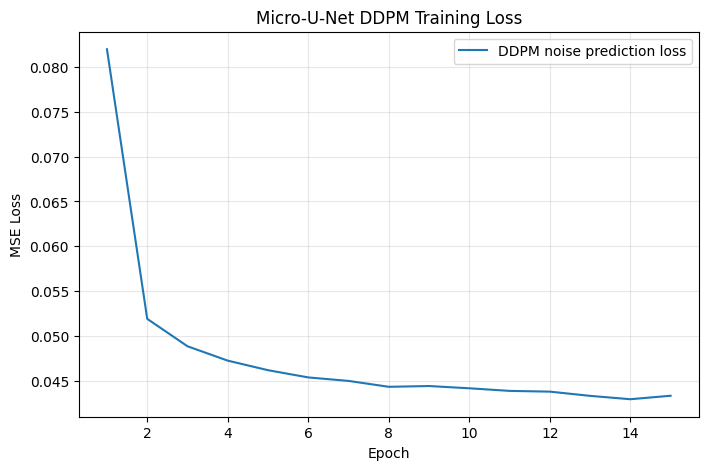

In [ ]:
epochs = range(1, len(ddpm_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, ddpm_losses, label="DDPM noise prediction loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Micro-U-Net DDPM Training Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Loading the Best MNIST DDPM Checkpoint

This cell loads the best saved Micro-U-Net DDPM checkpoint from Google Drive. The model architecture is reconstructed with the same image channels, base channels, and timestep embedding dimension used during training.

After loading the saved weights, the model is switched to evaluation mode. This ensures that the following reverse diffusion sampling step uses the best trained DDPM model for generating MNIST images.


In [ ]:
checkpoint = torch.load(
    best_ddpm_checkpoint_path,
    map_location=device,
    weights_only=False
)

best_ddpm_model = MicroUNet(
    image_channels=1,
    base_channels=32,
    time_dim=128
).to(device)

best_ddpm_model.load_state_dict(checkpoint["model_state_dict"])
best_ddpm_model.eval()

print("Loaded best DDPM model from epoch:", checkpoint["epoch"])
print("Best DDPM loss:", checkpoint["best_loss"])
print("T:", checkpoint["T"])

Loaded best DDPM model from epoch: 14
Best DDPM loss: 0.042911951380497866
T: 250


### Reverse Diffusion Sampling for MNIST

This cell implements the reverse diffusion process used to generate MNIST images with the trained DDPM. The function `p_sample` performs one denoising step, transforming an image from timestep `x_t` to `x_{t-1}` using the noise predicted by the Micro-U-Net.

The second function starts from pure random noise and repeatedly applies this reverse step until reaching the final generated image at `t = 0`. It also stores selected intermediate timesteps so that we can visualize how a digit gradually emerges from noise.


In [ ]:
# Reverse diffusion sampling

@torch.no_grad()
def p_sample(model, x, t):
    """
    One reverse diffusion step:
    x_t -> x_{t-1}
    """

    batch_size = x.size(0)

    t_tensor = torch.full(
        (batch_size,),
        t,
        device=device,
        dtype=torch.long
    )

    beta_t = extract(
        betas,
        t_tensor,
        x.shape
    )

    alpha_t = extract(
        alphas,
        t_tensor,
        x.shape
    )

    alpha_bar_t = extract(
        alpha_bars,
        t_tensor,
        x.shape
    )

    sqrt_one_minus_alpha_bar_t = extract(
        sqrt_one_minus_alpha_bars,
        t_tensor,
        x.shape
    )

    # Predict noise epsilon_theta(x_t, t)
    noise_pred = model(x, t_tensor)

    # DDPM reverse mean
    model_mean = (1.0 / torch.sqrt(alpha_t)) * (
        x - (beta_t / sqrt_one_minus_alpha_bar_t) * noise_pred
    )

    # At t=0, no more noise is added
    if t == 0:
        return model_mean

    noise = torch.randn_like(x)
    sigma_t = torch.sqrt(beta_t)

    return model_mean + sigma_t * noise


@torch.no_grad()
def sample_ddpm_with_steps(model, image_size=28, save_steps=None):
    """
    Generate one image from pure noise and save selected reverse timesteps.

    Intermediate timesteps are saved before the denoising step.
    The final t=0 image is saved after the last denoising step.
    """

    if save_steps is None:
        save_steps = [T - 1, 187, 124, 62, 0]

    model.eval()

    x = torch.randn(
        1,
        1,
        image_size,
        image_size,
        device=device
    )

    saved_images = {}

    for t in reversed(range(T)):

        # Save intermediate states before denoising.
        # Do not save t=0 here, because final t=0 should be after denoising.
        if t in save_steps and t != 0:
            saved_images[t] = x.detach().cpu()

        # Reverse diffusion step
        x = p_sample(
            model,
            x,
            t
        )

        # Save final generated image after the last step
        if t == 0 and 0 in save_steps:
            saved_images[0] = x.detach().cpu()

    return saved_images

### Visualizing MNIST Generation Across Reverse Diffusion Timesteps

This cell generates one MNIST image with the trained DDPM and stores 5 evenly spaced reverse diffusion timesteps. The process starts from pure noise and gradually denoises the image until the final digit is produced at `t = 0`.

The saved images are displayed side by side so that we can visualize how the reverse diffusion process progressively transforms noise into a recognizable handwritten digit. This is the main deliverable for Task 2.3.


Saved timesteps: [249, 187, 124, 62, 0]


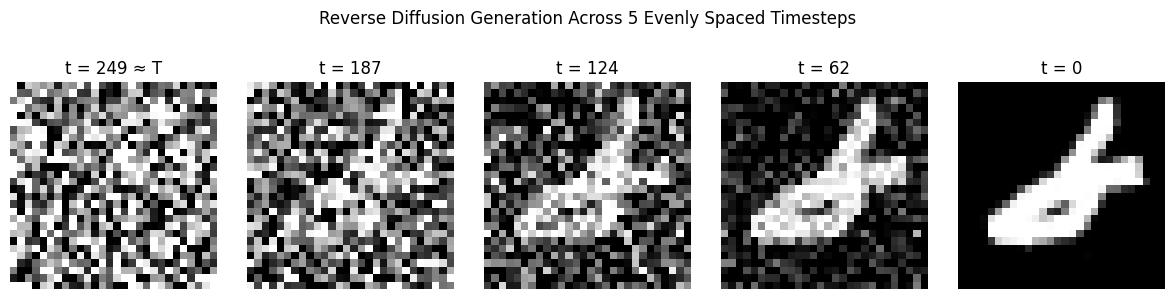

In [ ]:
save_steps = torch.linspace(T - 1, 0, steps=5).round().long().tolist()
print("Saved timesteps:", save_steps)

saved_images = sample_ddpm_with_steps(
    model=best_ddpm_model,
    image_size=28,
    save_steps=save_steps
)

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for ax, t in zip(axes, save_steps):
    img = saved_images[t]

    # Convert from [-1, 1] to [0, 1]
    img = (img + 1) / 2
    img = torch.clamp(img, 0, 1)

    ax.imshow(img.squeeze(), cmap="gray")

    if t == T - 1:
        ax.set_title(f"t = {t} ≈ T")
    else:
        ax.set_title(f"t = {t}")

    ax.axis("off")

plt.suptitle("Reverse Diffusion Generation Across 5 Evenly Spaced Timesteps")
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

### Part 3:  Accelerated Diffusion Sampling with DDIM

### DDIM Sampling Timesteps

This cell defines a reduced set of timesteps for DDIM sampling. Instead of using all `T = 250` reverse diffusion steps, we select only 50 evenly spaced timesteps from `T - 1` down to `0`.

This creates a faster deterministic sampling procedure compared with standard DDPM sampling. The printed acceleration factor shows how many fewer reverse steps are used during generation.


In [ ]:
DDIM_STEPS = 50

ddim_timesteps = torch.linspace(
    T - 1,
    0,
    steps=DDIM_STEPS
).round().long().tolist()

print("Number of DDIM steps:", len(ddim_timesteps))
print("First 10 DDIM timesteps:", ddim_timesteps[:10])
print("Last 10 DDIM timesteps:", ddim_timesteps[-10:])
print("Acceleration factor:", T / DDIM_STEPS)

Number of DDIM steps: 50
First 10 DDIM timesteps: [249, 244, 239, 234, 229, 224, 219, 213, 208, 203]
Last 10 DDIM timesteps: [46, 41, 36, 30, 25, 20, 15, 10, 5, 0]
Acceleration factor: 5.0


### One Deterministic DDIM Reverse Step

This cell defines one reverse sampling step for DDIM with `eta = 0`, making the sampling process deterministic. The model first predicts the noise present in the current noisy image `x_t` at timestep `t`.

Using this predicted noise, the function estimates the clean image `x_0` and then computes the previous sample `x_{t_prev}`. This allows us to generate images using fewer reverse steps than standard DDPM sampling, while still using the same trained noise prediction model.


In [ ]:
# One DDIM reverse step
# Deterministic DDIM sampling with eta = 0

@torch.no_grad()
def ddim_step(model, x_t, t, t_prev):
    """
    One deterministic DDIM reverse step:
    x_t -> x_{t_prev}
    """

    batch_size = x_t.size(0)

    t_tensor = torch.full(
        (batch_size,),
        t,
        device=device,
        dtype=torch.long
    )

    # Predict noise epsilon_theta(x_t, t)
    eps_pred = model(x_t, t_tensor)

    alpha_bar_t = alpha_bars[t].view(1, 1, 1, 1)

    if t_prev >= 0:
        alpha_bar_prev = alpha_bars[t_prev].view(1, 1, 1, 1)
    else:
        alpha_bar_prev = torch.tensor(1.0, device=device).view(1, 1, 1, 1)

    # Estimate clean image x_0
    x0_pred = (
        x_t - torch.sqrt(1.0 - alpha_bar_t) * eps_pred
    ) / torch.sqrt(alpha_bar_t)

    # Keep predicted image in valid normalized range
    x0_pred = torch.clamp(x0_pred, -1.0, 1.0)

    # Deterministic DDIM update
    x_prev = (
        torch.sqrt(alpha_bar_prev) * x0_pred
        + torch.sqrt(1.0 - alpha_bar_prev) * eps_pred
    )

    return x_prev, x0_pred

### Full DDIM Sampling Function

This cell defines the complete deterministic DDIM sampling procedure. The function starts from pure Gaussian noise and applies a reduced sequence of reverse timesteps instead of using all DDPM steps.

At each step, the trained Micro-U-Net predicts the noise and the DDIM update produces the next less-noisy image. Selected intermediate states are saved for visualization, while the final image at `t = 0` is saved after the last denoising step. This allows faster image generation compared with standard DDPM sampling.


In [ ]:
# Full DDIM sampling function
# Final version: includes final denoising step at t = 0

@torch.no_grad()
def sample_ddim(model, image_size=28, ddim_steps=50, save_timesteps=None):
    """
    Generate one image using deterministic DDIM sampling.

    Returns:
        final_img
        saved_images
        ddim_timesteps
    """

    model.eval()

    ddim_timesteps = torch.linspace(
        T - 1,
        0,
        steps=ddim_steps
    ).round().long().tolist()

    if save_timesteps is None:
        save_timesteps = [
            ddim_timesteps[0],
            ddim_timesteps[len(ddim_timesteps) // 4],
            ddim_timesteps[len(ddim_timesteps) // 2],
            ddim_timesteps[(3 * len(ddim_timesteps)) // 4],
            ddim_timesteps[-1]
        ]

    # Start from pure Gaussian noise
    x = torch.randn(
        1,
        1,
        image_size,
        image_size,
        device=device
    )

    saved_images = {}

    for i, t in enumerate(ddim_timesteps):

        # Save current noisy state before denoising,
        # except for t=0, which we save after the final denoising step.
        if t in save_timesteps and t != 0:
            saved_images[t] = x.detach().cpu()

        if i == len(ddim_timesteps) - 1:
            # Final denoising step: t = 0 -> clean x0
            t_prev = -1
        else:
            t_prev = ddim_timesteps[i + 1]

        x, x0_pred = ddim_step(
            model=model,
            x_t=x,
            t=t,
            t_prev=t_prev
        )

    # Save final clean image as t = 0
    saved_images[0] = x.detach().cpu()

    final_img = x.detach().cpu()

    return final_img, saved_images, ddim_timesteps

### Running DDIM Sampling

This cell runs the DDIM sampler using the trained MNIST DDPM model. Instead of using all 250 DDPM reverse steps, it generates an image using only 50 deterministic DDIM steps.

The printed information confirms that sampling was completed successfully, shows the number of timesteps used, and lists the saved intermediate states. These saved states are used later to visualize the faster DDIM generation process.


In [ ]:
final_img, saved_images, ddim_timesteps = sample_ddim(
    model=best_ddpm_model,
    image_size=28,
    ddim_steps=50
)

print("DDIM sampling complete.")
print("Number of timesteps used:", len(ddim_timesteps))
print("First timestep:", ddim_timesteps[0])
print("Last timestep:", ddim_timesteps[-1])
print("Saved timesteps:", list(saved_images.keys()))

DDIM sampling complete.
Number of timesteps used: 50
First timestep: 249
Last timestep: 0
Saved timesteps: [249, 188, 122, 61, 0]


### Visualizing DDIM Generation Across Timesteps

This cell visualizes the DDIM sampling process at 5 selected timesteps. Starting from a very noisy image, the sampler gradually refines the image until a final handwritten digit is produced.

The images are converted back from `[-1, 1]` to `[0, 1]` for display. This plot shows how DDIM can generate a digit in fewer reverse steps than standard DDPM sampling, while still producing a meaningful result.


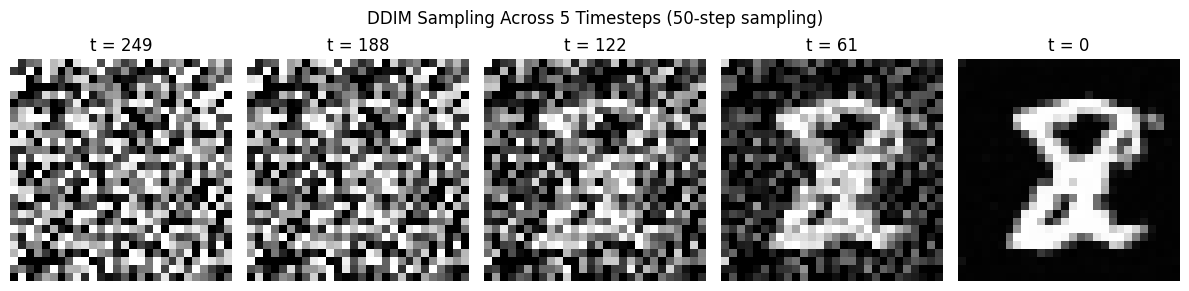

In [ ]:
save_timesteps = [
    ddim_timesteps[0],
    ddim_timesteps[len(ddim_timesteps) // 4],
    ddim_timesteps[len(ddim_timesteps) // 2],
    ddim_timesteps[(3 * len(ddim_timesteps)) // 4],
    ddim_timesteps[-1]
]

final_img, saved_images, ddim_timesteps = sample_ddim(
    model=best_ddpm_model,
    image_size=28,
    ddim_steps=50,
    save_timesteps=save_timesteps
)

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for ax, t in zip(axes, save_timesteps):
    img = saved_images[t]

    # Convert from [-1, 1] to [0, 1]
    img = (img + 1) / 2
    img = torch.clamp(img, 0, 1)

    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"t = {t}")
    ax.axis("off")

plt.suptitle("DDIM Sampling Across 5 Timesteps (50-step sampling)")
plt.tight_layout()
plt.show()

### Generating Multiple MNIST Digits with DDIM

This cell uses the DDIM sampler repeatedly to generate 25 MNIST-like digits with only 50 reverse diffusion steps per sample. Each final generated image is collected and then arranged into a 5 × 5 grid for visualization.

This provides a qualitative evaluation of the accelerated DDIM sampler. It allows us to check whether the model can still generate recognizable handwritten digits while using far fewer sampling steps than standard DDPM generation.


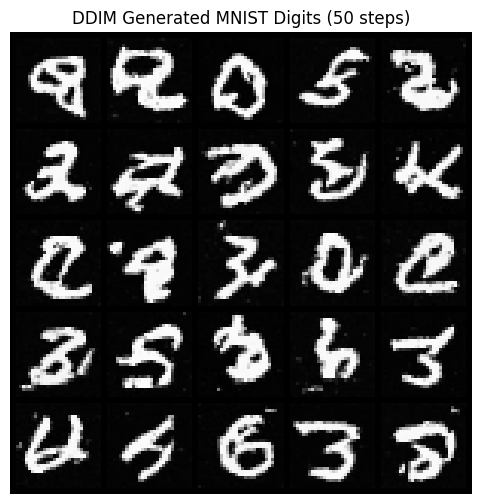

In [ ]:
ddim_samples = []

for _ in range(25):
    final_img, _, _ = sample_ddim(
        model=best_ddpm_model,
        image_size=28,
        ddim_steps=50
    )

    ddim_samples.append(final_img)

ddim_samples = torch.cat(ddim_samples, dim=0)

# Convert from [-1, 1] to [0, 1]
ddim_samples = (ddim_samples + 1) / 2
ddim_samples = torch.clamp(ddim_samples, 0, 1)

grid = make_grid(
    ddim_samples,
    nrow=5,
    padding=2
)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title("DDIM Generated MNIST Digits (50 steps)")
plt.show()